# ClaimStruct CX Classifier

## Exploratory Data Analysis for Banking Claims
Portfolio Project | Deep Learning and NLP


## Project Overview
This notebook documents the exploratory analysis for a Spanish-language banking claims dataset used to train NLP models for customer-support automation.

The analysis is designed for an external technical audience and focuses on three goals:
1. Understand the dataset structure and statistical behavior.
2. Detect risks that can bias model evaluation (especially leakage in synthetic data).
3. Derive actionable constraints for downstream modeling (token length, class imbalance, split quality, and NER annotation health).


## Reproducibility Note
During execution, the notebook may request the `claimstruct_multitable_v2.zip` file. Load the archive through the notebook file-upload utility when prompted.


## Implementation: Imports and Dependencies


If dependency installation fails in a clean environment, uncomment the optional installation commands below.


In [124]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import defaultdict
from sklearn.model_selection import StratifiedShuffleSplit

import os
import re
import zipfile
import json
import random
import textwrap

warnings.filterwarnings("ignore")

## Methodology: Configuration and Reproducibility


In [125]:
@dataclass
class Config:
    # --- Configuracion de visualizacion ---
    palette: list = field(default_factory=lambda: [
        '#a5c4beff',  # verde salvia suave
        '#ffc0c0ff',  # rosa pastel
        '#3f5a6bff',  # azul petróleo
        '#f38681ff',  # coral suave
        '#00c3b1ff',  # turquesa vibrante
        '#6c8ea3ff',  # azul grisáceo medio
        '#b8a1c9ff',  # lavanda apagada
        '#f2b880ff',  # durazno cálido
        '#7bbfa5ff',  # verde menta medio
        '#d97d54ff',  # terracota suave
    ])
    bg_color: str = "#f7ecdcff" # Color de fondo de las figuras
    fig_w: int = 8             # Ancho de las figuras en pulgadas
    fig_h: int = 4              # Alto de las figuras en pulgadas
    dpi: int = 130              # Resolucion de las figuras
    sample_pairplot: int = 2000 # Cantidad de muestras para el pairplot (evita graficos lentos)
    seed: int = 42              # Semilla para reproducibilidad
    bert_model_name: str = "dccuchile/bert-base-spanish-wwm-cased" # Modelo BERT a utilizar para entrenamiento
    n_augments: int = 3              # Numero de variantes por conversación para estrategia de augmentation

# Instanciar configuracion global
cfg = Config()

# Fijar semillas para garantizar reproducibilidad en NumPy
np.random.seed(cfg.seed)
random.seed(cfg.seed)

In [126]:
sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": cfg.bg_color,
        "axes.facecolor": cfg.bg_color
    }
)

## Implementation: Utility Functions


In [127]:
def anonimizar_texto(texto: str) -> str:
    """
    Reemplaza menciones al banco por un token anonimo.
    Cubre variantes: itau, Itau, itaú, Itaú, ITAU, banco itau,
    Itaú: (seguido de dos puntos) etc.
    """
    patrones = [
        r"[Bb]anco\s+[Ii]ta[uú][eé]?s?\s*:?",   # banco itau, Banco Itaú:
        r"[Ii]ta[uú]\s+[Bb]anco\s*:?",            # itau banco:
        r"[Ii]ta[uú][eé]?s?\s*:?",                # itau, Itaú, itaues, Itaú:
        r"ITAU[EÉ]?S?\s*:?",                       # ITAU, ITAUES, ITAU:
    ]

    patron_combinado = "|".join(patrones)

    return re.sub(patron_combinado, "[BANCO]", texto)

### Visualization Helpers
Reusable plotting helpers standardize style, labeling, and scaling across all diagnostic charts to keep comparisons consistent.


In [128]:
def plot_barh(series: pd.Series, ax: plt.Axes, title: str,
              xlabel: str = "Frecuencia", palette: str = "viridis",
              top_n: int = 20, color: str = None,
              color_map: dict = None) -> None:
    """Barras horizontales a partir de un value_counts o Series ordenado."""
    data = series.head(top_n)

    if color_map:
        # Color distinto por categoria usando mapa compartido
        colors = [color_map[idx] for idx in data.index]
    elif color:
        # Color unico para todas las barras
        colors = color
    else:
        # Color distinto por posicion usando palette
        colors = sns.color_palette(palette, len(data))

    data.plot.barh(ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

In [129]:
def plot_hist(series: pd.Series, ax: plt.Axes, title: str,
              xlabel: str = "", bins: int = 60, log: bool = False, color: str = "steelblue") -> None:
    """Histograma con linea de mediana."""
    series.hist(bins=bins, ax=ax, color=color, edgecolor="white", log=log)
    ax.axvline(series.median(), color="red", ls="--", lw=1.2, label=f"Mediana={series.median():.0f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

In [130]:
def plot_heatmap(ct: pd.DataFrame, ax: plt.Axes, title: str,
                 fmt: str = "d", cmap: str = "YlOrRd") -> None:
    """Heatmap generico sobre una tabla de contingencia o correlacion."""
    sns.heatmap(ct, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(title)

In [131]:
def plot_heatmap_corr(corr: pd.DataFrame, ax: plt.Axes, title: str,
                      cmap: str = "RdBu_r") -> None:
    """Heatmap triangular para matrices de correlacion."""
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title)

In [132]:
def plot_stacked_pct(ct: pd.DataFrame, ax: plt.Axes, title: str,
                     cmap: str = "tab10") -> None:
    """Barras horizontales apiladas al 100% a partir de un crosstab."""
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Si cmap es una lista de colores, crear un colormap desde ella
    if isinstance(cmap, list):
        from matplotlib.colors import ListedColormap
        cmap = ListedColormap(cmap)

    ct_pct.plot.barh(stacked=True, ax=ax, colormap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Porcentaje")
    ax.invert_yaxis()
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

### Data and Validation Helpers
Helper functions cover extraction, integrity checks, aggregation, sampling, and safe cross-tab generation to reduce repetitive code and prevent silent data-quality failures.


In [133]:
def extract_zip(zip_path: str, extract_dir: str) -> None:
    """
    Extract a zip into `extract_dir`, resolving paths from the current notebook
    working directory.

    If `zip_path` is empty, it defaults to `<extract_dir>.zip`.
    """
    cwd = os.getcwd()

    zip_name = zip_path.strip() if zip_path and zip_path.strip() else f"{extract_dir}.zip"
    zip_file = zip_name if os.path.isabs(zip_name) else os.path.join(cwd, zip_name)

    extract_target = extract_dir if os.path.isabs(extract_dir) else os.path.join(cwd, extract_dir)

    if not os.path.exists(zip_file):
        raise FileNotFoundError(f"Zip file not found: {zip_file}")

    os.makedirs(extract_target, exist_ok=True)
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(extract_target)

    print(f"Extracted: {zip_file} -> {extract_target}")


def safe_read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

In [134]:
def mostrar_conversaciones_random(df, n_conversations=3):
    conv_ids = df["conversation_id"].dropna().unique()

    selected_convs = random.sample(
        list(conv_ids),
        min(n_conversations, len(conv_ids))
    )

    for cid in selected_convs:
        df_conv = df[df["conversation_id"] == cid] \
            .sort_values("timestamp_offset_sec")

        # Tomar reason_code_primary (puede repetirse dentro de la conv)
        reason = df_conv["reason_code_primary"].dropna().iloc[0] \
            if "reason_code_primary" in df_conv.columns else "UNKNOWN"

        print("\n" + "="*80)
        print(f"CONVERSATION ID: {cid}")
        print(f"REASON CODE: {reason}")
        print("="*80)

        for _, row in df_conv.iterrows():

            print(f"[{row['speaker'].upper()}] {row['text']}")
            print()

        print("="*80 + "\n")

In [135]:
def check_col(df: pd.DataFrame, col: str) -> bool:
    """Verifica que la columna exista y tenga datos no nulos."""
    return col in df.columns and df[col].notna().any()

In [136]:
def crosstab_safe(df: pd.DataFrame, row: str, col: str) -> Optional[pd.DataFrame]:
    """Crosstab solo si ambas columnas tienen datos."""
    if check_col(df, row) and check_col(df, col):
        return pd.crosstab(df[row], df[col])
    return None

In [137]:
def agregar_por_conversacion(messages: pd.DataFrame, entities: pd.DataFrame) -> pd.DataFrame:
    """Calcula metricas agregadas por conversacion: mensajes, palabras, duracion, entidades."""
    # Agrupa los mensajes por conversacion y calcula metricas de texto y duracion
    msg_agg = messages.groupby("conversation_id").agg(
        # Cantidad total de mensajes en la conversacion
        n_msgs=("message_id", "size"),
        # Total de palabras sumando las palabras de cada mensaje
        total_words=("text", lambda x: x.astype(str).str.split().str.len().sum()),
        # Total de caracteres sumando la longitud de cada mensaje
        total_chars=("text", lambda x: x.astype(str).str.len().sum()),
        # Duracion en segundos
        duracion_sec=("timestamp_offset_sec", lambda x: x.max() - x.min()),
    ).reset_index()

    # Agrupa las entidades por conversacion y calcula metricas de entidades
    ent_agg = entities.groupby("conversation_id").agg(
        # Cantidad total de entidades detectadas en la conversacion
        n_entities=("entity_type", "size"),
        # Cantidad de tipos de entidades distintos (ej: PERSON, ORG, DATE...)
        n_entity_types=("entity_type", "nunique"),
    ).reset_index()

    # Une ambas tablas por conversation_id usando left join para conservar
    # todas las conversaciones, incluso las que no tienen entidades
    df = msg_agg.merge(ent_agg, on="conversation_id", how="left")

    # Las conversaciones sin entidades quedan con NaN tras el merge,
    # se reemplazan por 0
    df[["n_entities", "n_entity_types"]] = df[["n_entities", "n_entity_types"]].fillna(0).astype(int)

    return df

In [138]:
def print_dataframe_info(name: str, df: pd.DataFrame) -> None:
    """
    Imprime información estructural básica de un DataFrame.
    """
    print("\n" + "=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumnas:")
    print(list(df.columns))

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nValores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))

    print("\nMemoria aproximada en MB:")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 3))

    print("\nEstadísticas descriptivas:")
    print(df.describe(include="all"))

In [139]:
def print_multiple_dataframes_info(dfs: dict) -> None:
    """
    Recibe un diccionario {nombre: dataframe} y muestra info para cada uno.
    """
    print("===== INFORMACIÓN GENERAL =====")
    for name, df in dfs.items():
        print_dataframe_info(name, df)

In [140]:
def compute_tsne(texts: pd.Series, n_pca: int = 50,
                 n_sample: int = 2000, seed: int = 42,
                 max_features: int = 5000) -> Tuple[np.ndarray, np.ndarray, PCA]:
    """Pipeline TF-IDF → PCA → t-SNE. Retorna coordenadas 2D, índices del sample y el PCA."""
    tfidf = TfidfVectorizer(max_features=max_features, sublinear_tf=True)
    X = tfidf.fit_transform(texts)

    pca = PCA(n_components=n_pca, random_state=seed)
    X_pca = pca.fit_transform(X.toarray())

    n_s = min(n_sample, len(texts))
    idx = np.random.choice(len(texts), n_s, replace=False)

    tsne = TSNE(n_components=2, random_state=seed, perplexity=30)
    X_2d = tsne.fit_transform(X_pca[idx])

    return X_2d, idx, pca

def plot_tsne_scatter(X_2d: np.ndarray, labels_arr: np.ndarray,
                      ax: plt.Axes, title: str,
                      palette: list, s: int = 12, alpha: float = 0.6,
                      mask: np.ndarray = None) -> None:
    """Scatter plot coloreado por categoría."""
    if mask is None:
        mask = np.ones(len(labels_arr), dtype=bool)

    unique = sorted(set(labels_arr[mask]))
    for i, cat in enumerate(unique):
        m = (labels_arr == cat) & mask
        if m.any():
            ax.scatter(X_2d[m, 0], X_2d[m, 1],
                       label=cat, s=s, alpha=alpha,
                       color=palette[i % len(palette)])

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

## Data Ingestion


In [141]:
extract_dir = "claimstruct_multitable_v2"
extract_zip("", extract_dir)

Extracted: /Users/jnahui/Desktop/Proyects.nosync/Jeasmine.github.io/cx_classifier/claimstruct_multitable_v2.zip -> /Users/jnahui/Desktop/Proyects.nosync/Jeasmine.github.io/cx_classifier/claimstruct_multitable_v2


In [142]:
conversations_path = os.path.join(extract_dir, "conversations.csv")
messages_path = os.path.join(extract_dir, "messages.csv")
labels_path = os.path.join(extract_dir, "labels.csv")
entities_path = os.path.join(extract_dir, "entities.csv")

conversations = safe_read_csv(conversations_path)
messages = safe_read_csv(messages_path)
labels = safe_read_csv(labels_path)
entities = safe_read_csv(entities_path)

In [143]:
print("Shapes:")
for n, df in [("messages", messages), ("labels", labels),
              ("entities", entities), ("conversations", conversations)]:
    print(f"  {n}: {df.shape}")

Shapes:
  messages: (46713, 5)
  labels: (8000, 13)
  entities: (16502, 9)
  conversations: (8000, 10)


## Problem Definition
The project addresses automated understanding of customer-service conversations in retail banking. The target use case is internal decision support, not chatbot response generation.

Primary tasks:
1. Intent classification at conversation level.
2. Entity extraction for key operational fields.

The EDA section establishes whether the dataset supports reliable training and evaluation for these tasks.


### Data Quality and Integrity Checks


In [144]:
print_multiple_dataframes_info({
    "Conversations": conversations,
    "Messages": messages,
    "Labels": labels,
    "Entities": entities
})

# ─── Resumen general (dinámico) ───
n_conv = len(conversations)
n_msgs = len(messages)
n_ents = len(entities)
n_labs = len(labels)
msgs_per_conv = n_msgs / n_conv
ents_per_conv = n_ents / n_conv
mem_total_mb = sum(
    df.memory_usage(deep=True).sum()
    for df in [conversations, messages, labels, entities]
) / 1024**2

n_unique_texts = messages["text"].nunique() if "text" in messages.columns else 0
top_text = messages["text"].value_counts().head(1)
top_text_name, top_text_count = top_text.index[0], top_text.values[0]

null_intent_sec = labels["intent_secondary"].isna().sum() if "intent_secondary" in labels.columns else 0
null_pct = null_intent_sec / n_labs * 100

top_channel = conversations["channel"].value_counts().head(1)
ch_name, ch_count = top_channel.index[0], top_channel.values[0]
ch_pct = ch_count / n_conv * 100

top_intent = labels["intent_primary"].value_counts().head(1)
int_name, int_count = top_intent.index[0], top_intent.values[0]
int_pct = int_count / n_conv * 100

n_canales = conversations["channel"].nunique()
n_intents = labels["intent_primary"].nunique()

speaker_counts = messages["speaker"].value_counts()
customer_count = speaker_counts.get("customer", 0)
agent_count = speaker_counts.get("agent", 0)
customer_pct = customer_count / n_msgs * 100
agent_pct = agent_count / n_msgs * 100

===== INFORMACIÓN GENERAL =====

CONVERSATIONS

Shape:
(8000, 10)

Columnas:
['conversation_id', 'created_at', 'channel', 'language', 'customer_segment', 'country', 'product_hint', 'is_synthetic', 'dataset_version', 'split']

Tipos de datos:
conversation_id      str
created_at           str
channel              str
language             str
customer_segment     str
country              str
product_hint         str
is_synthetic        bool
dataset_version      str
split                str
dtype: object

Valores nulos por columna:
conversation_id     0
created_at          0
channel             0
language            0
customer_segment    0
country             0
product_hint        0
is_synthetic        0
dataset_version     0
split               0
dtype: int64

Memoria aproximada en MB:
4.07

Estadísticas descriptivas:
       conversation_id           created_at channel language customer_segment  \
count             8000                 8000    8000     8000             8000   
unique     

The dataset is organized in four relational tables:
- `conversations` (8,000 rows)
- `messages` (46,713 rows)
- `labels` (8,000 rows)
- `entities` (16,502 rows)

The conversation is the analytical unit, while messages provide sequential text evidence. Null-value checks show strong overall data quality; missing values are concentrated in optional label fields.


In [145]:
print(f"\n{'='*65}")
print("RESUMEN GENERAL DEL DATASET")
print(f"{'='*65}")
print(f"\n  Volumen: {n_conv:,} conversaciones | {n_msgs:,} mensajes | "
      f"{n_ents:,} entidades | {n_labs:,} labels")
print(f"  Promedios: {msgs_per_conv:.1f} msgs/conv | {ents_per_conv:.1f} ents/conv")
print(f"  Memoria total: ~{mem_total_mb:.1f} MB")
print(f"\n  Textos únicos en mensajes: {n_unique_texts:,} de {n_msgs:,} "
      f"(más frecuente: \"{top_text_name}\" con {top_text_count:,} ocurrencias)")
print(f"  intent_secondary nulos: {null_intent_sec:,} ({null_pct:.1f}%) — no viable para entrenamiento")
print(f"\n  Canales: {n_canales} | dominante: {ch_name} ({ch_count:,}, {ch_pct:.1f}%)")
print(f"  Intents: {n_intents} | dominante: {int_name} ({int_count:,}, {int_pct:.1f}%)")
print(f"  Speakers: customer {customer_count:,} ({customer_pct:.1f}%) | "
      f"agent {agent_count:,} ({agent_pct:.1f}%)")
print(f"{'='*65}")

print("""\n**Resumen general** (ver estadísticas computadas arriba)

El dataset es 100% sintético, monolingue en español y geográficamente concentrado
en Uruguay. Las tablas conversations, messages y entities no presentan valores nulos.
La excepción es labels, donde intent_secondary tiene un porcentaje alto de nulos,
lo que la hace no viable para entrenamiento; se utiliza exclusivamente intent_primary
como objetivo de clasificación.

El alto reuso de frases en los mensajes es característico de datos sintéticos y
es un factor a monitorear durante el entrenamiento, ya que podría afectar la
capacidad de generalización del modelo.

Los campos severity, fraud_risk, outcome y routing_queue están disponibles como
candidatos para futuras tareas multitask, y el campo confidence de entities
permitiría filtrar por umbral de calidad si se detecta ruido.
""")


RESUMEN GENERAL DEL DATASET

  Volumen: 8,000 conversaciones | 46,713 mensajes | 16,502 entidades | 8,000 labels
  Promedios: 5.8 msgs/conv | 2.1 ents/conv
  Memoria total: ~29.4 MB

  Textos únicos en mensajes: 3,271 de 46,713 (más frecuente: "Gracias." con 1,655 ocurrencias)
  intent_secondary nulos: 6,549 (81.9%) — no viable para entrenamiento

  Canales: 6 | dominante: chat (3,512, 43.9%)
  Intents: 8 | dominante: rechazo_prevencion_fraude (2,400, 30.0%)
  Speakers: customer 33,282 (71.2%) | agent 13,431 (28.8%)

**Resumen general** (ver estadísticas computadas arriba)

El dataset es 100% sintético, monolingue en español y geográficamente concentrado
en Uruguay. Las tablas conversations, messages y entities no presentan valores nulos.
La excepción es labels, donde intent_secondary tiene un porcentaje alto de nulos,
lo que la hace no viable para entrenamiento; se utiliza exclusivamente intent_primary
como objetivo de clasificación.

El alto reuso de frases en los mensajes es caract

## Data Description
Initial inspection validates schema compatibility across tables and confirms that keys required for joins (`conversation_id`, `message_id`) are structurally usable for conversation-level modeling.


In [146]:
conversations.head()

,conversation_id,created_at,channel,language,customer_segment,country,product_hint,is_synthetic,dataset_version,split
0,conv_000001,2025-03-18T11:24:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
1,conv_000002,2025-05-01T03:49:00,app,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
2,conv_000003,2025-04-24T17:16:00,callcenter,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
3,conv_000004,2025-02-17T08:07:00,chat,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
4,conv_000005,2025-02-15T20:14:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,test


In [147]:
messages["text"] = messages["text"].astype(str).apply(anonimizar_texto)

In [148]:
messages.head()

,conversation_id,message_id,speaker,timestamp_offset_sec,text
0,conv_000001,conv_000001_msg_001,customer,0,"Hola, buenas. Soy Valentina. Estoy intentando ..."
1,conv_000001,conv_000001_msg_002,customer,31,Me figura autorización rechazada por 89.00 EUR.
2,conv_000001,conv_000001_msg_003,agent,57,"Bien, reviso seguridad. ¿La compra es por inte..."
3,conv_000001,conv_000001_msg_004,customer,79,Es por internet desde Estados Unidos. En el su...
4,conv_000001,conv_000001_msg_005,agent,108,Soporte: Puede ser prevención de fraude. Podem...


In [149]:
labels.head()

,conversation_id,intent_primary,intent_secondary,product_final,reason_code_primary,severity,fraud_risk,outcome,routing_queue,label_source,labeler_id,label_version,split
0,conv_001706,rechazo_prevencion_fraude,fraude_desconocimiento,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,escalated,cards_ops,synthetic,generator,v1,train
1,conv_006186,acreditacion_transferencia,acreditacion_pago,transferencia,no_acredita_transferencia,low,low,resolved,accounts_ops,synthetic,generator,v1,train
2,conv_000900,rechazo_prevencion_fraude,NaN,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,resolved,cards_ops,synthetic,generator,v1,train
3,conv_007454,acceso_canales_digitales,NaN,canales_digitales,problema_acceso_clave,low,low,resolved,digital_support,synthetic,generator,v1,train
4,conv_002773,controversia_compra,NaN,tarjeta_credito,controversia_compra,medium,low,escalated,cards_ops,synthetic,generator,v1,train


In [150]:
entities.head()

,conversation_id,message_id,entity_type,start_char,end_char,text_span,normalized_value,confidence,extractor_source
0,conv_000001,conv_000001_msg_002,amount,38,43,89.00,89.00,0.95,synthetic
1,conv_000001,conv_000001_msg_002,currency,44,47,EUR,EUR,0.91,synthetic
2,conv_000001,conv_000001_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.94,synthetic
3,conv_000002,conv_000002_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.88,synthetic
4,conv_000003,conv_000003_msg_002,amount,38,43,"59,99","59,99",0.96,synthetic


In [151]:
messages_labels = pd.merge(
    messages,
    labels,
    on=["conversation_id"],
    how="left"
)

In [152]:
# Este dataframe es la base de todo el analisis cruzado.
conv_stats = agregar_por_conversacion(messages, entities)
n_before_merge = len(conv_stats)
conv_stats = conv_stats.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id", how="inner")
n_after_merge = len(conv_stats)

if n_before_merge != n_after_merge:
    print(f"ADVERTENCIA: {n_before_merge - n_after_merge} conversaciones "
          f"sin labels fueron descartadas en el merge "
          f"({n_before_merge} → {n_after_merge}).")
else:
    print(f"Merge exitoso: {n_after_merge} conversaciones con labels (sin pérdidas).")

Merge exitoso: 8000 conversaciones con labels (sin pérdidas).


In [153]:
mostrar_conversaciones_random(
    messages_labels,
    n_conversations=3
)


CONVERSATION ID: conv_005239
REASON CODE: otros_reclamos_cuenta
[CUSTOMER] Buenas. Soy Lucía. Tengo una consulta sobre mi cuenta.

[CUSTOMER] me figura un débito automático que no reconozco en la cuenta.

[AGENT] Revisamos el detalle y te indico el procedimiento o sector.

[CUSTOMER] Lucía: Perfecto, quedo atento/a.

[AGENT] Asesor/a: Te dejo registrado el caso y próximos pasos.

[CUSTOMER] Lucía: Me pasó también ayer, por eso consulto.

[AGENT] Asesor/a: Entiendo. Te hago unas preguntas de validación y dejamos todo asentado.

[CUSTOMER] Lucía: Dale, decime.

[CUSTOMER] Listo, gracias.



CONVERSATION ID: conv_000913
REASON CODE: autorizacion_rechazada_prevencion_fraude
[CUSTOMER] Buenas. Soy Rodrigo. Estoy intentando pagar y me rechaza la tarjeta de crédito.

[CUSTOMER] Me figura autorización rechazada en Amazon .

[AGENT] Bien, reviso seguridad. ¿La compra es por internet o internacional?

[CUSTOMER] a ver Es por internet desde Brasil. En el super me dejó, acá no.

[AGENT] Atención 

## Methodology: Univariate and Bivariate Analysis
This section evaluates class distributions, channel/product composition, textual length behavior, and metadata relationships to assess modeling feasibility and expected failure modes.


### Primary Reason Distribution


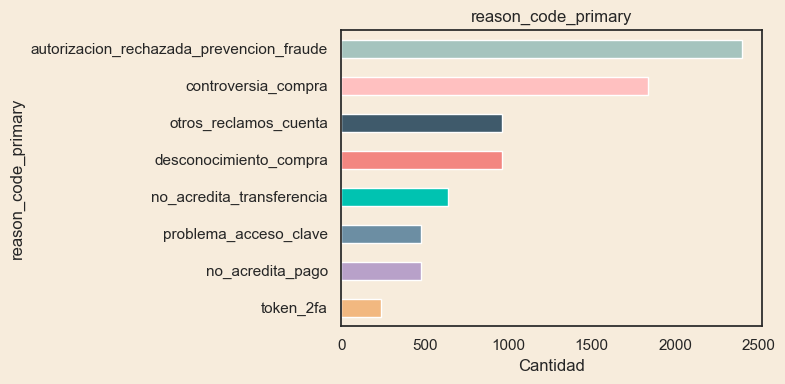

In [154]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=labels["reason_code_primary"].value_counts(),
    ax=ax,
    title="reason_code_primary",
    xlabel="Cantidad",
    palette=cfg.palette
)

plt.tight_layout()
plt.show()

### Intent Distribution


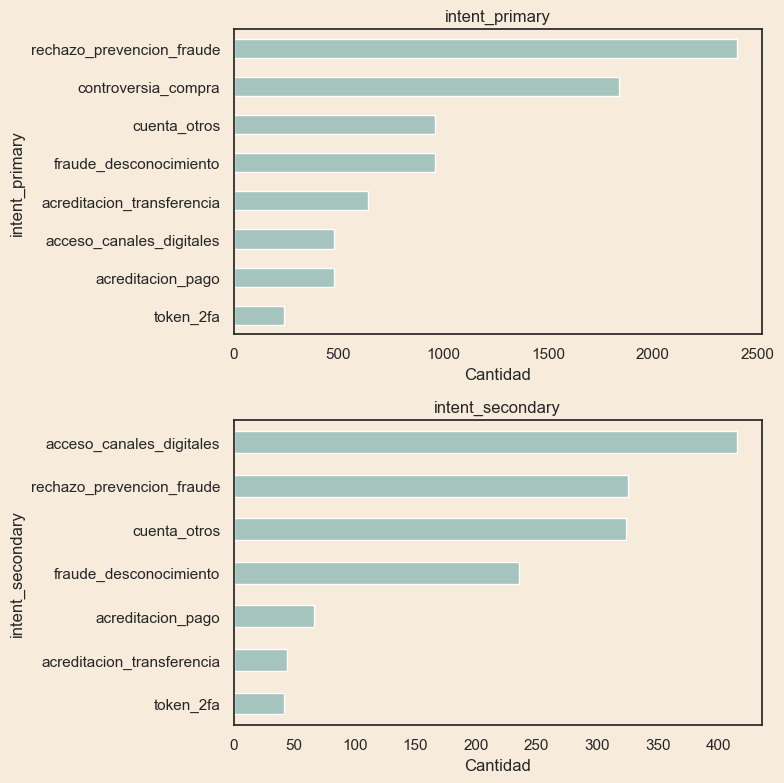

In [155]:
# Construir mapa de colores compartido por categoria
all_intents = list(set(
    labels["intent_primary"].dropna().unique().tolist() +
    labels["intent_secondary"].dropna().unique().tolist()
))

palette_map = {
    intent: color
    for intent, color in zip(all_intents, sns.color_palette(cfg.palette, len(all_intents)))
}

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

plot_barh(
    series=labels["intent_primary"].value_counts(),
    ax=axes[0],
    title="intent_primary",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette[0],
    # color_map=palette_map
)

if check_col(labels, "intent_secondary"):
    plot_barh(
        series=labels["intent_secondary"].value_counts(),
        ax=axes[1],
        title="intent_secondary",
        xlabel="Cantidad",
        color = cfg.palette[0],
        # palette=cfg.palette[0],
        # color_map=palette_map
    )

plt.tight_layout()
plt.show()

Intent distribution shows moderate imbalance, with `rechazo_prevencion_fraude` and `controversia_compra` as dominant classes. `intent_secondary` is sparsely populated and is therefore excluded from supervised targets.

Product and channel distributions are operationally coherent: card-related products dominate and chat is the primary channel. Severity and fraud-risk labels are concentrated in low/medium tiers, with fewer high-severity events.

These patterns are realistic for support operations and justify class-weighting and macro-level metrics in modeling.


### Product Distribution


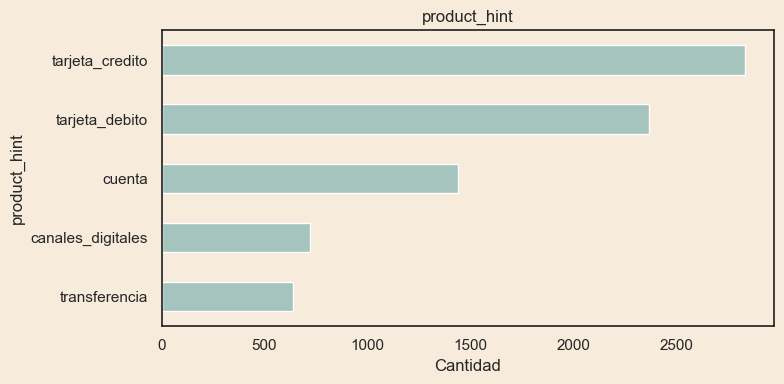

In [156]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=conversations["product_hint"].value_counts(),
    ax=ax,
    title="product_hint",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette
)

plt.tight_layout()
plt.show()

#### Product Consistency: `product_hint` vs `product_final`
`product_hint` captures the initial user-reported context, while `product_final` reflects post-classification assignment. Their agreement rate is used as a consistency signal and as a proxy for ambiguity in early routing.


In [157]:
prod_check = conversations[["conversation_id", "product_hint"]].merge(
    labels[["conversation_id", "product_final"]],
    on="conversation_id"
)

prod_check["match"] = prod_check["product_hint"] == prod_check["product_final"]
match_rate = prod_check["match"].mean() * 100

print(f"Coincidencia product_hint vs product_final: {match_rate:.1f}%")
print(f"Discrepancias: {(~prod_check['match']).sum()} de {len(prod_check)}")

if match_rate < 100:
    ct_prod = pd.crosstab(
        prod_check["product_hint"],
        prod_check["product_final"]
    )

    fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h * 1.5))
    plot_heatmap(ct_prod, ax, "product_hint vs product_final", fmt="d", cmap="YlOrRd")
    plt.tight_layout()
    plt.show()
else:
    print("Ambas columnas son idénticas en todas las conversaciones.")

Coincidencia product_hint vs product_final: 100.0%
Discrepancias: 0 de 8000
Ambas columnas son idénticas en todas las conversaciones.


### Channel Distribution


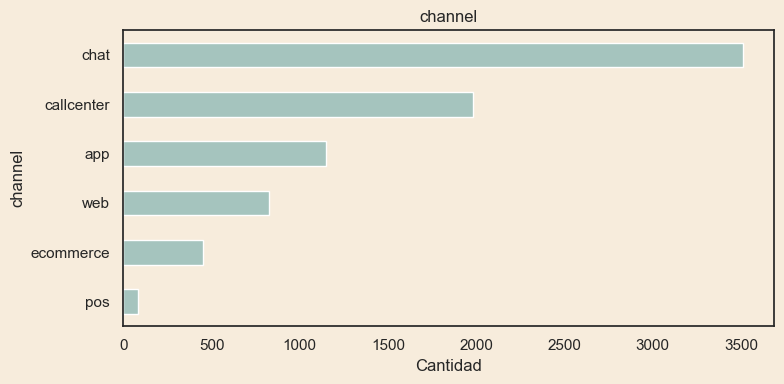

In [158]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=conversations["channel"].value_counts(),
    ax=ax,
    title="channel",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette
)

plt.tight_layout()
plt.show()

### Label Categories (`severity`, `fraud_risk`, `outcome`, `routing_queue`)


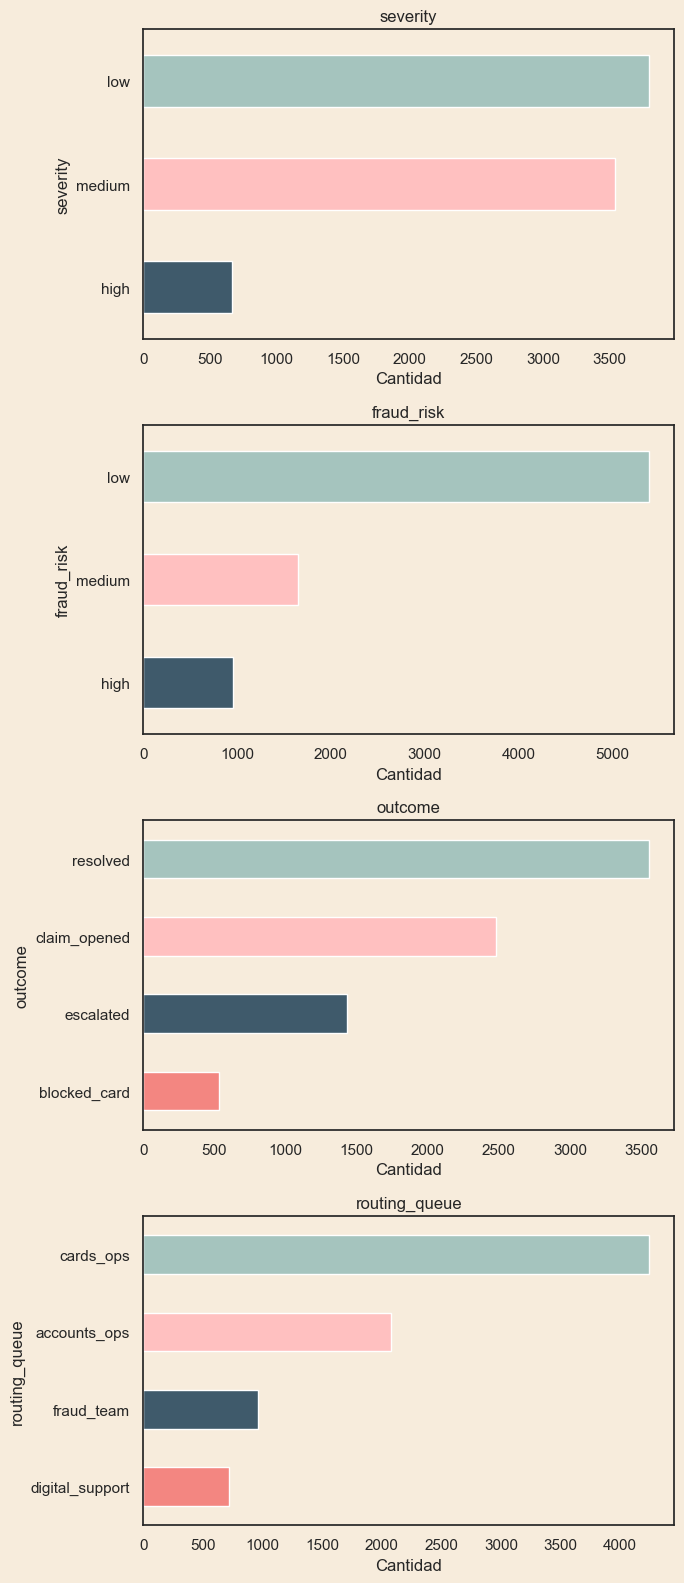

In [159]:
cat_cols = [
    c for c in ["severity", "fraud_risk", "outcome", "routing_queue"]
    if check_col(labels, c)
]

if cat_cols:
    fig, axes = plt.subplots(
        len(cat_cols),
        1,
        figsize=(7, 4 * len(cat_cols))
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cat_cols):
        plot_barh(
            series=labels[col].value_counts(),
            ax=ax,
            title=col,
            xlabel="Cantidad",
            palette=cfg.palette
        )

    plt.tight_layout()
    plt.show()

Category-level analysis confirms expected operational relationships:
- Fraud-related intents align with higher severity and specialist routing.
- Card products map strongly to `cards_ops`.
- Most outcomes are resolved or formally opened claims.

From a modeling perspective, intent imbalance is the most relevant risk and should be handled through loss weighting and class-sensitive evaluation.


**Split quality warning (original split):** this view corresponds to the original dataset split and reveals substantial message-level leakage. Later sections introduce a revised split strategy to reduce overlap of repeated text across partitions.


### Message Length Analysis


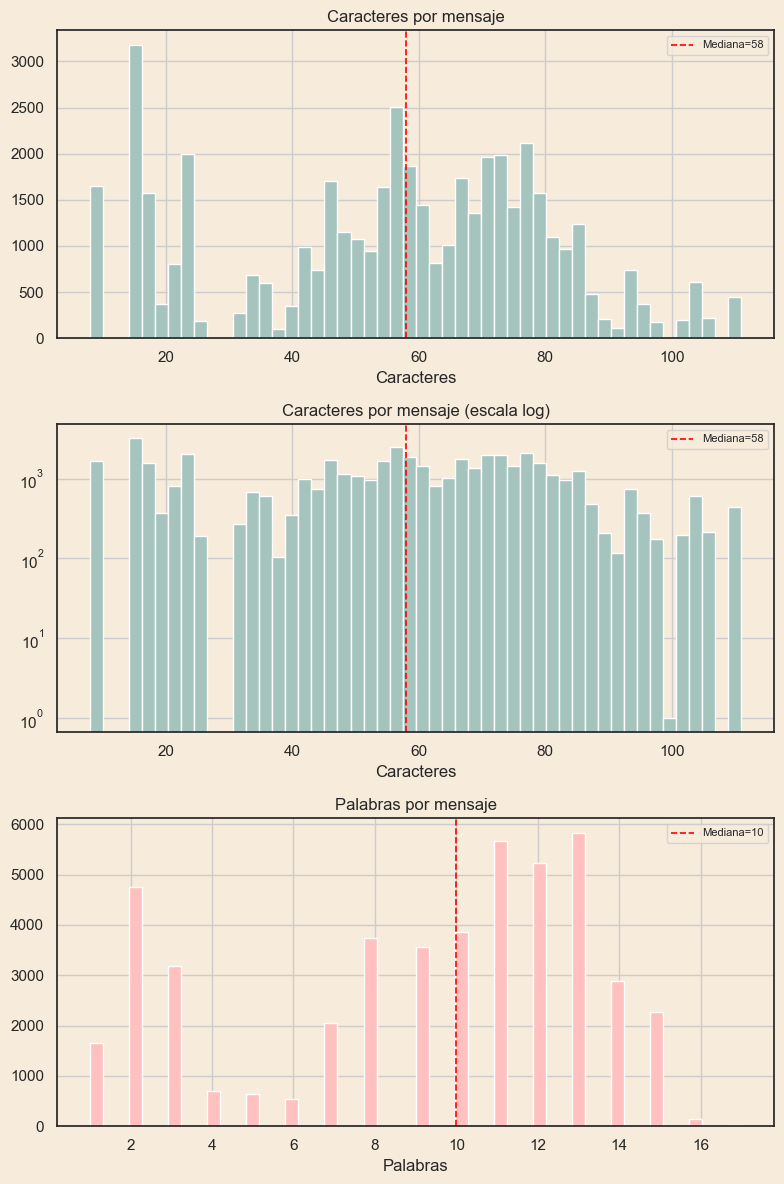



       text_len_chars  text_len_words
count         46713.0         46713.0
mean             55.7             9.0
std              25.1             4.2
min               8.0             1.0
25%              39.0             7.0
50%              58.0            10.0
75%              74.0            12.0
max             111.0            17.0


In [160]:
# Features
messages["text_len_chars"] = messages["text"].astype(str).str.len()
messages["text_len_words"] = messages["text"].astype(str).str.split().str.len()

# Figura
fig, axes = plt.subplots(3, 1, figsize=(cfg.fig_w, cfg.fig_h * 3))

plot_hist(messages["text_len_chars"], axes[0],
          title="Caracteres por mensaje",
          xlabel="Caracteres",
          bins=50,
          color=cfg.palette[0])

plot_hist(messages["text_len_chars"], axes[1],
          title="Caracteres por mensaje (escala log)",
          xlabel="Caracteres",
          bins=50,
          log=True,
          color=cfg.palette[0])

plot_hist(messages["text_len_words"], axes[2],
          title="Palabras por mensaje",
          xlabel="Palabras",
          bins=50,
          color=cfg.palette[1])

plt.tight_layout()
plt.show()

# Estadísticos
print("\n")
print(messages[["text_len_chars", "text_len_words"]]
      .describe()
      .round(1))

Message length is bimodal: short transactional utterances and longer explanatory turns. This pattern is expected in support dialogs and supports conversation-level concatenation.

Token-budget estimation indicates that `max_length=256` comfortably covers the dataset for BERT-style encoding, including special tokens and separators.


### Message Timing (`timestamp_offset_sec`)


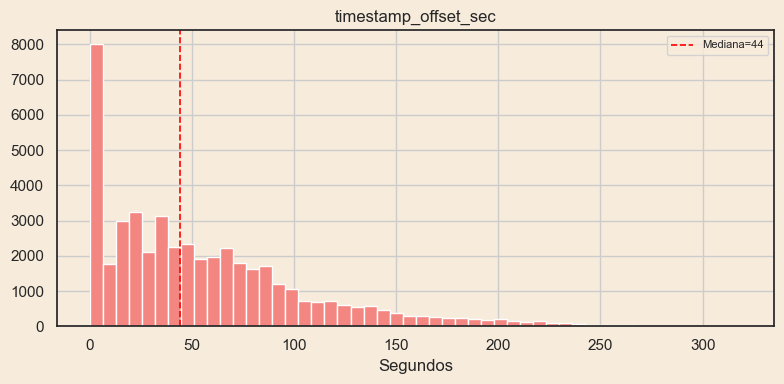

In [161]:
fig, ax = plt.subplots(1, figsize=(cfg.fig_w, cfg.fig_h))

plot_hist(
    series=messages["timestamp_offset_sec"],
    ax=ax,
    title="timestamp_offset_sec",
    xlabel="Segundos",
    bins=50,
    color=cfg.palette[3]
)

plt.tight_layout()
plt.show()

### Length and Duration by Intent


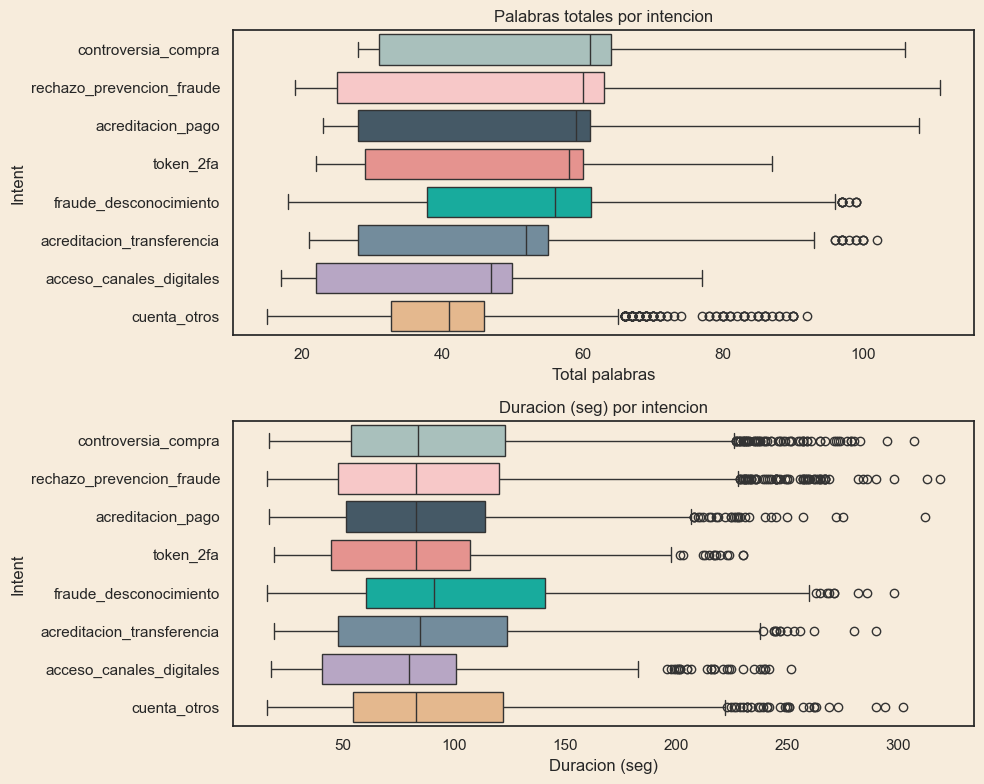

In [162]:
order_intent = (
    conv_stats
    .groupby("intent_primary")["total_words"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Palabras totales por intención
sns.boxplot(
    data=conv_stats,
    x="total_words",
    y="intent_primary",
    order=order_intent,
    ax=axes[0],
    palette=cfg.palette
)

axes[0].set_title("Palabras totales por intencion")
axes[0].set_xlabel("Total palabras")
axes[0].set_ylabel("Intent")

# Duración en segundos por intención
sns.boxplot(
    data=conv_stats,
    x="duracion_sec",
    y="intent_primary",
    order=order_intent,
    ax=axes[1],
    palette=cfg.palette
)

axes[1].set_title("Duracion (seg) por intencion")
axes[1].set_xlabel("Duracion (seg)")
axes[1].set_ylabel("Intent")

plt.tight_layout()
plt.show()

Length and timing distributions are operationally stable: most conversations are short, with controlled variance and limited extreme outliers.

Implication for training:
- Sequence truncation risk is low.
- Compute cost remains predictable.
- Intent groups differ in conversational density, which can provide useful discriminative signal.


### Conversation-Level Length
The model consumes concatenated conversation text. Therefore, conversation-level token statistics are the relevant constraint for architecture and hyperparameter choices.


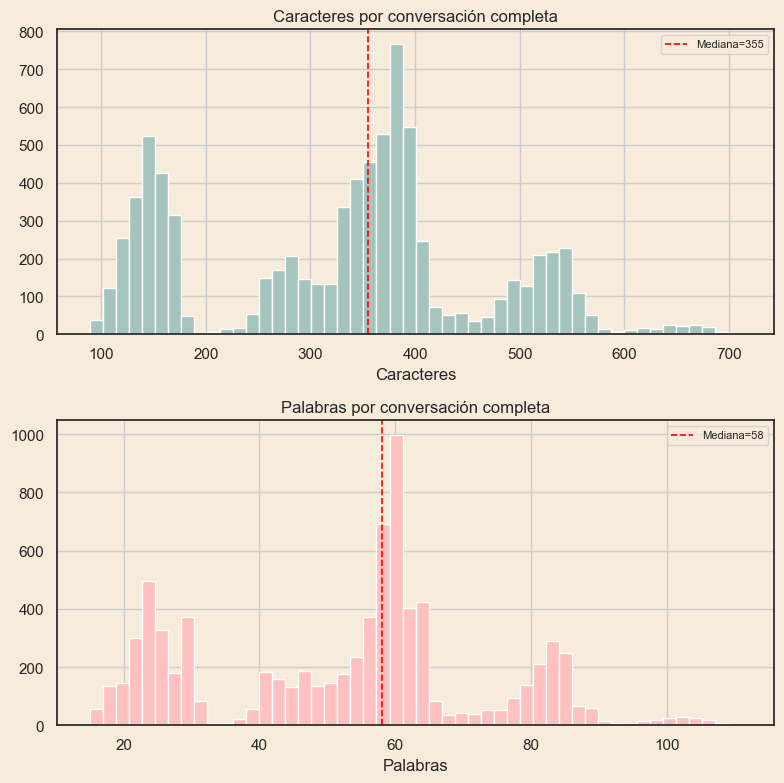


Estadísticas de conversaciones completas:
       total_chars  total_words  n_msgs
count       8000.0       8000.0  8000.0
mean         330.4         52.8     5.8
std          135.6         20.9     2.1
min           89.0         15.0     3.0
25%          173.0         30.0     3.0
50%          355.0         58.0     6.0
75%          396.0         62.0     6.0
max          712.0        111.0    11.0
  P90: 523 chars, 83 palabras
  P95: 545 chars, 85 palabras
  P99: 645 chars, 101 palabras


In [163]:
conv_full = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .agg(
        full_text=lambda x: " ".join(x.astype(str)),
        n_msgs="count"
    )
    .reset_index()
)
conv_full["total_chars"] = conv_full["full_text"].str.len()
conv_full["total_words"] = conv_full["full_text"].str.split().str.len()

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

plot_hist(conv_full["total_chars"], axes[0],
          title="Caracteres por conversación completa",
          xlabel="Caracteres", bins=50, color=cfg.palette[0])

plot_hist(conv_full["total_words"], axes[1],
          title="Palabras por conversación completa",
          xlabel="Palabras", bins=50, color=cfg.palette[1])

plt.tight_layout()
plt.show()

print("\nEstadísticas de conversaciones completas:")
print(conv_full[["total_chars", "total_words", "n_msgs"]].describe().round(1))

# Percentiles clave para dimensionar max_length
for p in [90, 95, 99]:
    chars_p = conv_full["total_chars"].quantile(p / 100)
    words_p = conv_full["total_words"].quantile(p / 100)
    print(f"  P{p}: {chars_p:.0f} chars, {words_p:.0f} palabras")

### Real Token-Length Audit
Word-count heuristics are validated against the real tokenizer (`dccuchile/bert-base-spanish-wwm-cased`) to measure true subword lengths and confirm padding/truncation strategy.


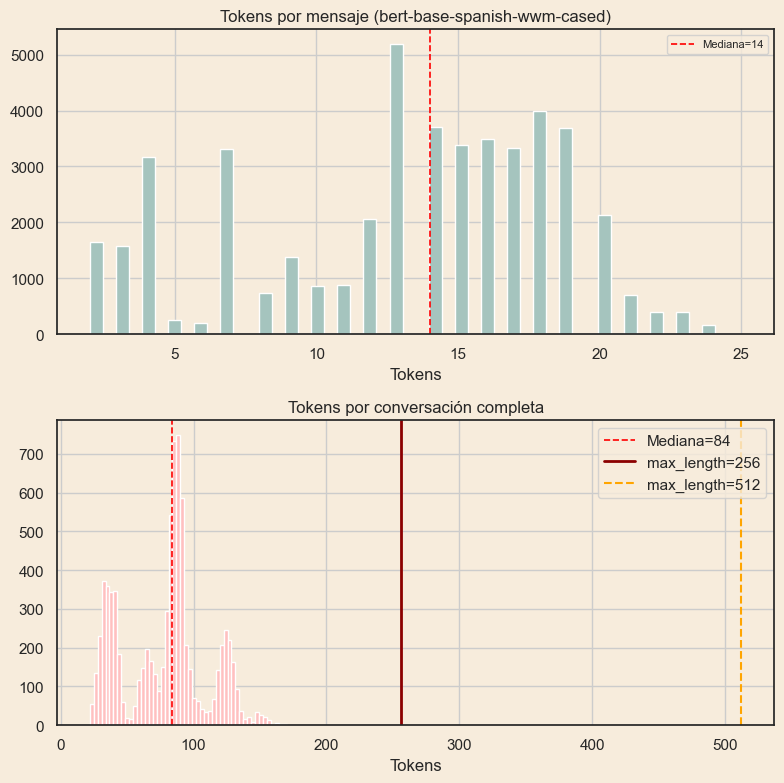


Tokenizer: dccuchile/bert-base-spanish-wwm-cased
Tokens por conversación completa:
count    8000.0
mean       78.5
std        31.6
min        22.0
25%        45.0
50%        84.0
75%        93.0
max       170.0
Name: n_tokens, dtype: float64

  Conversaciones > 256 tokens: 0.0%
  Conversaciones > 512 tokens: 0.0%

  Ratio real tokens/palabra: 1.49

 max_length=256 cubre el 100.0% de las conversaciones.


In [165]:
try:
    from transformers import AutoTokenizer

    MODEL_NAME = cfg.bert_model_name
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Tokenizar mensajes individuales
    messages["n_tokens"] = messages["text"].astype(str).apply(
        lambda x: len(tokenizer.encode(x, add_special_tokens=False))
    )

    # Tokenizar conversaciones completas (reutilizar conv_full de sección 3.7)
    conv_full["n_tokens"] = conv_full["full_text"].apply(
        lambda x: len(tokenizer.encode(x, add_special_tokens=True))
    )

    fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

    plot_hist(messages["n_tokens"], axes[0],
              title=f"Tokens por mensaje ({MODEL_NAME.split('/')[-1]})",
              xlabel="Tokens", bins=50, color=cfg.palette[0])

    plot_hist(conv_full["n_tokens"], axes[1],
              title=f"Tokens por conversación completa",
              xlabel="Tokens", bins=50, color=cfg.palette[1])

    # Línea de referencia en max_length=256
    axes[1].axvline(256, color="darkred", ls="-", lw=2, label="max_length=256")
    axes[1].axvline(512, color="orange", ls="--", lw=1.5, label="max_length=512")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Estadísticas y verificación del claim
    pct_over_256 = (conv_full["n_tokens"] > 256).mean() * 100
    pct_over_512 = (conv_full["n_tokens"] > 512).mean() * 100

    print(f"\nTokenizer: {MODEL_NAME}")
    print(f"Tokens por conversación completa:")
    print(conv_full["n_tokens"].describe().round(1))
    print(f"\n  Conversaciones > 256 tokens: {pct_over_256:.1f}%")
    print(f"  Conversaciones > 512 tokens: {pct_over_512:.1f}%")

    # Ratio tokens/palabra real vs. estimación del EDA original
    ratio = conv_full["n_tokens"].sum() / conv_full["total_words"].sum()
    print(f"\n  Ratio real tokens/palabra: {ratio:.2f}")

    if pct_over_256 > 5:
        print(f"\n⚠ ALERTA: {pct_over_256:.1f}% de conversaciones exceden 256 tokens.")
        print("  Considerar aumentar max_length o truncar con estrategia.")
    else:
        print(f"\n max_length=256 cubre el {100-pct_over_256:.1f}% de las conversaciones.")

except ImportError:
    print("INFO: 'transformers' no instalado. Se omite análisis de tokens.")
    print("      Instalar con: pip install transformers")

### Messages per Conversation


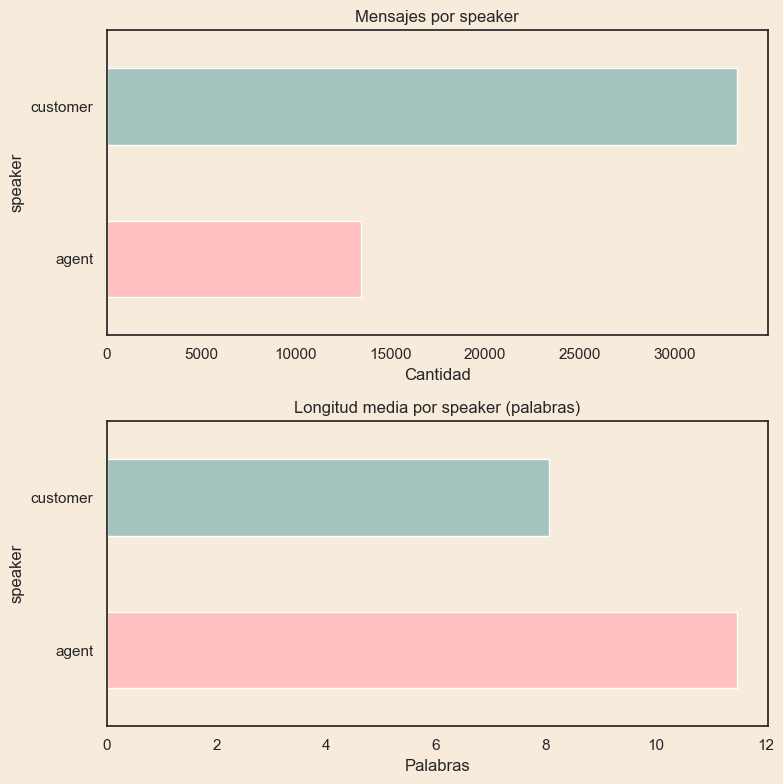

In [166]:
fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

# Mensajes por speaker
plot_barh(
    series=messages["speaker"].value_counts(),
    ax=axes[0],
    title="Mensajes por speaker",
    xlabel="Cantidad",
    palette=cfg.palette
)

# Longitud media por speaker
plot_barh(
    series=messages.groupby("speaker")[
        "text_len_words"].mean().sort_values(ascending=True),
    ax=axes[1],
    title="Longitud media por speaker (palabras)",
    xlabel="Palabras",
    palette=cfg.palette
)

plt.tight_layout()
plt.show()

In [167]:
# ─── Estadísticas por speaker (dinámico) ───
_speaker_counts = messages["speaker"].value_counts()
_speaker_mean_words = messages.groupby("speaker")["text_len_words"].mean()
_cust_n = _speaker_counts.get("customer", 0)
_agent_n = _speaker_counts.get("agent", 0)
_cust_words = _speaker_mean_words.get("customer", 0)
_agent_words = _speaker_mean_words.get("agent", 0)

print(f"\nSpeaker stats:")
print(f"  customer: {_cust_n:,} intervenciones | promedio {_cust_words:.2f} palabras/msg")
print(f"  agent:    {_agent_n:,} intervenciones | promedio {_agent_words:.2f} palabras/msg")

print("""Se observa que la mayoría de los turnos corresponden al cliente. En términos
de longitud promedio, los mensajes del agente son más extensos que los del cliente,
lo que sugiere que el cliente tiende a formular reclamos de manera más breve y
directa, mientras que el agente produce respuestas relativamente más desarrolladas.""")


Speaker stats:
  customer: 33,282 intervenciones | promedio 8.07 palabras/msg
  agent:    13,431 intervenciones | promedio 11.47 palabras/msg
Se observa que la mayoría de los turnos corresponden al cliente. En términos
de longitud promedio, los mensajes del agente son más extensos que los del cliente,
lo que sugiere que el cliente tiende a formular reclamos de manera más breve y
directa, mientras que el agente produce respuestas relativamente más desarrolladas.


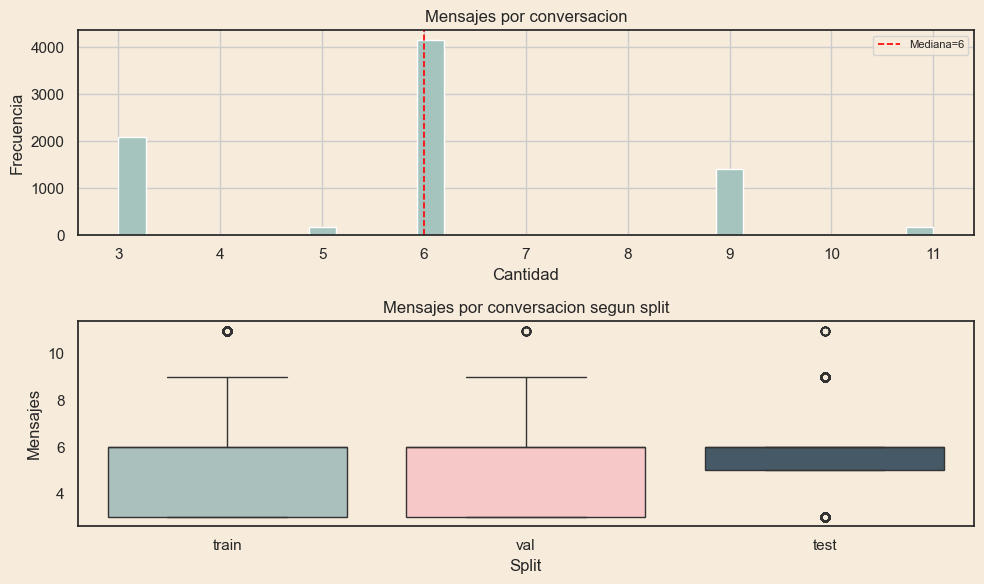

In [168]:
msgs_per_conv = (
    messages
    .groupby("conversation_id")
    .size()
    .reset_index(name="n_msgs")
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_hist(
    series=msgs_per_conv["n_msgs"],
    ax=axes[0],
    title="Mensajes por conversacion",
    xlabel="Cantidad",
    bins=30,
    color=cfg.palette[0]
)

axes[0].set_title("Mensajes por conversacion")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Frecuencia")

conv_split = msgs_per_conv.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

sns.boxplot(
    data=conv_split,
    x="split",
    y="n_msgs",
    order=["train", "val", "test"],
    palette=cfg.palette,
    ax=axes[1]
)

axes[1].set_title("Mensajes por conversacion segun split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Mensajes")

plt.tight_layout()
plt.show()

The median conversation contains approximately six messages, with most interactions concentrated between three and nine turns. This supports a compact but information-rich representation per sample.


### Correlation Analysis


#### Intent vs Operational Categories


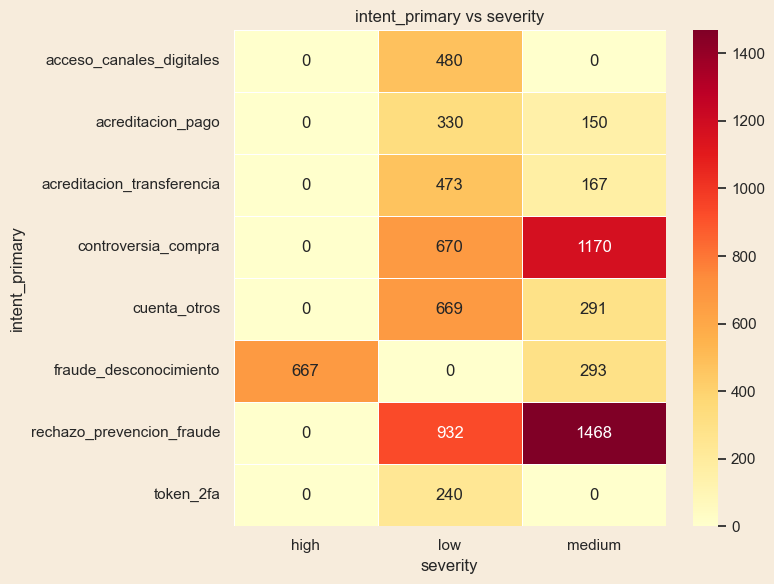

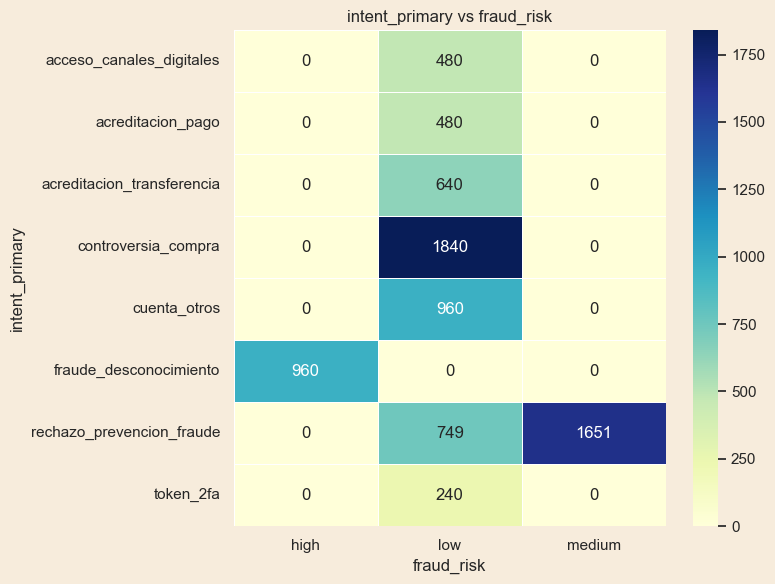

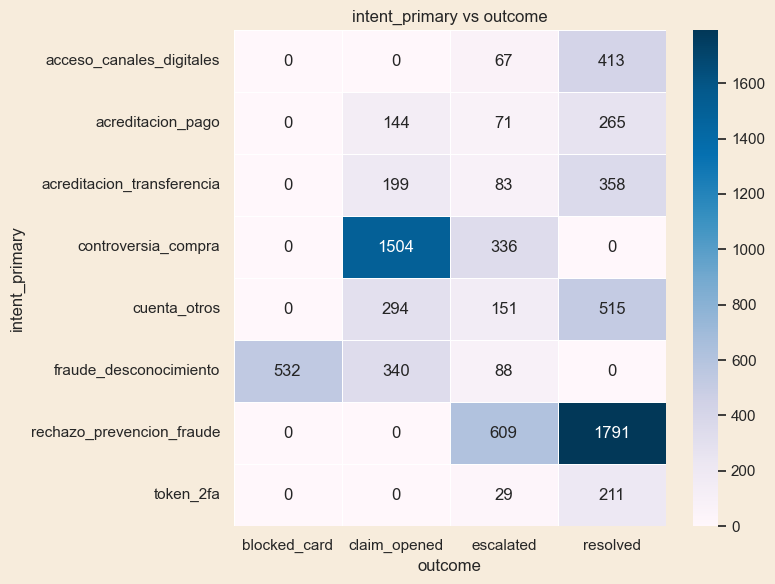

In [169]:
cruces = [
    ("severity", "YlOrRd"),
    ("fraud_risk", "YlGnBu"),
    ("outcome", "PuBu"),
]

for col, cmap in cruces:
    ct = crosstab_safe(labels, "intent_primary", col)

    if ct is not None:
        fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h * 1.5))

        plot_heatmap(
            ct=ct,
            ax=ax,
            title=f"intent_primary vs {col}",
            fmt="d",
            cmap=cmap
        )

        plt.tight_layout()
        plt.show()

Cross-tab heatmaps show semantically coherent dependencies:
- Fraud intents are associated with higher severity and escalation-heavy outcomes.
- Simpler access intents are resolved more often in first contact.

These relationships suggest potential value in multi-task or auxiliary-signal strategies during modeling.


### Entity Analysis: Distribution and Span Characteristics


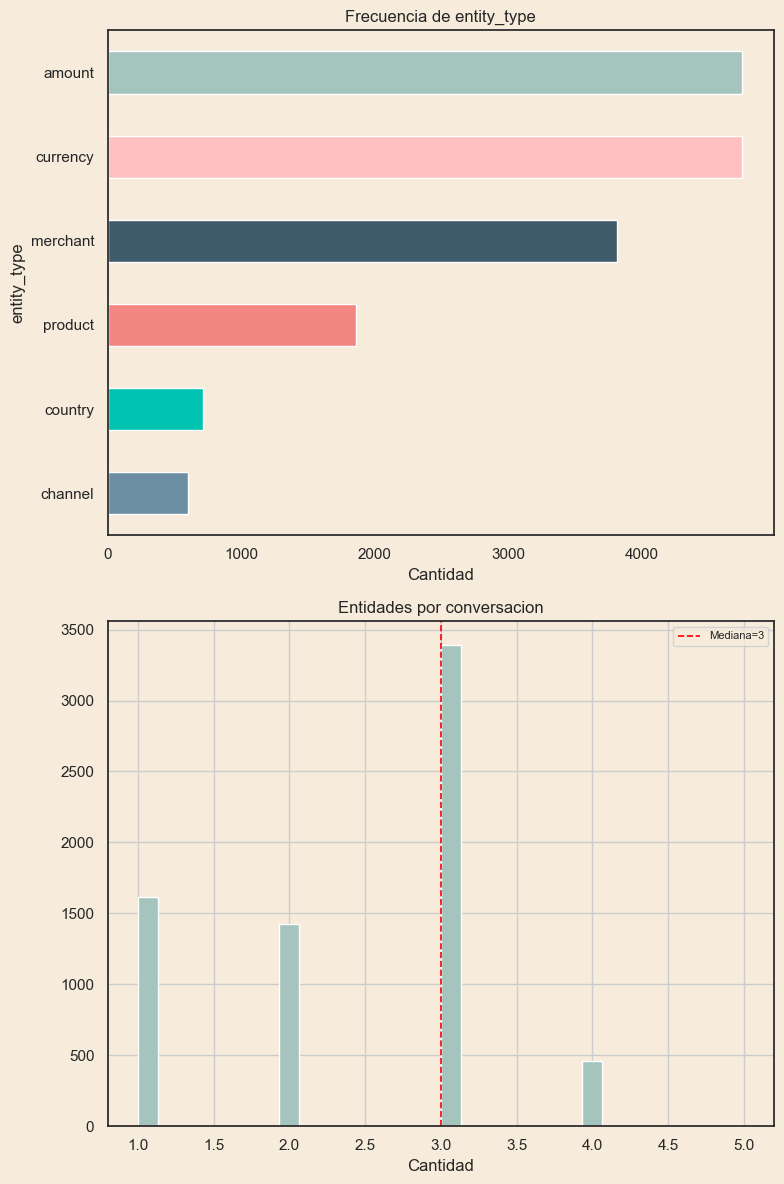

In [170]:
entities["span_len"] = (
    entities["end_char"] - entities["start_char"]
).clip(lower=0)

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 3))

plot_barh(
    series=entities["entity_type"].value_counts(),
    ax=axes[0],
    title="Frecuencia de entity_type",
    xlabel="Cantidad",
    palette=cfg.palette
)

plot_hist(
    series=entities.groupby("conversation_id").size(),
    ax=axes[1],
    title="Entidades por conversacion",
    xlabel="Cantidad",
    bins=30,
    color=cfg.palette[0]
)

plt.tight_layout()
plt.show()

Entity density is moderate, with most conversations containing between one and four entities. This is favorable for token-level labeling because entity boundaries remain frequent enough for learning but not overly saturated.


#### Entity Confidence Distribution
Confidence scores are inspected to evaluate whether low-certainty entities should be filtered before NER training.


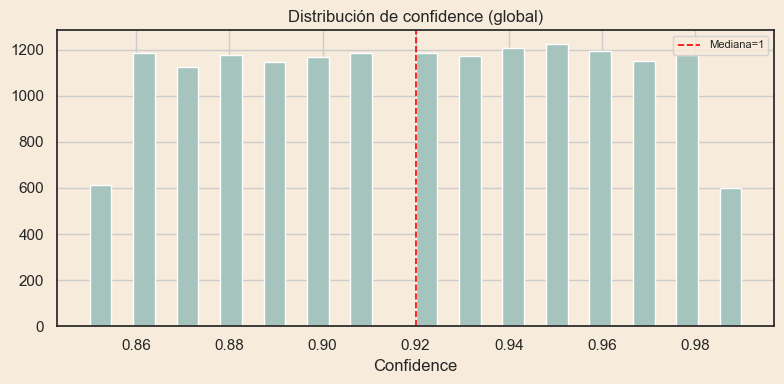

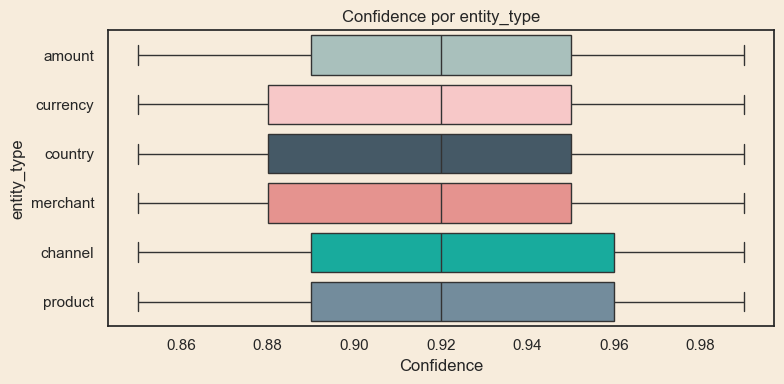


Entidades por debajo de umbrales de confianza:
  confidence < 0.95: 11,162 (67.6%)
  confidence < 0.9: 5,245 (31.8%)
  confidence < 0.85: 0 (0.0%)


In [171]:
# Histograma global de confidence
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
plot_hist(
    entities["confidence"],
    ax,
    title="Distribución de confidence (global)",
    xlabel="Confidence",
    bins=30,
    color=cfg.palette[0]
)
plt.tight_layout()
plt.show()

# Boxplot por tipo de entidad
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
sns.boxplot(
    data=entities,
    x="confidence",
    y="entity_type",
    hue="entity_type",
    palette=cfg.palette,
    ax=ax,
    legend=False
)
ax.set_title("Confidence por entity_type")
ax.set_xlabel("Confidence")
plt.tight_layout()
plt.show()

# Porcentaje bajo umbrales comunes
print("\nEntidades por debajo de umbrales de confianza:")
for threshold in [0.95, 0.90, 0.85]:
    n_below = (entities["confidence"] < threshold).sum()
    pct = n_below / len(entities) * 100
    print(f"  confidence < {threshold}: {n_below:,} ({pct:.1f}%)")

#### Span Validation
Span integrity (`start_char`, `end_char`, `text_span`) is validated because misaligned spans directly corrupt BIO labels and reduce NER reliability.


In [172]:
# Extraer substring usando las posiciones anotadas
def extract_span_safe(row):
    """Extrae text[start:end] verificando límites."""
    text = str(row["text"]) if pd.notna(row["text"]) else ""
    start = int(row["start_char"])
    end = int(row["end_char"])
    if end <= len(text) and start >= 0:
        return text[start:end]
    return None  # fuera de rango

In [173]:
# Merge entidades con el texto del mensaje fuente
ent_val = entities.merge(
    messages[["message_id", "text"]],
    on="message_id",
    how="left"
)

ent_val["extracted_span"] = ent_val.apply(extract_span_safe, axis=1)
ent_val["span_match"] = ent_val["extracted_span"] == ent_val["text_span"]

# Reportar resultados
n_total = len(ent_val)
n_oob = ent_val["extracted_span"].isna().sum()
n_match = ent_val["span_match"].sum()
n_mismatch = n_total - n_match - n_oob

print("=" * 65)
print("VALIDACIÓN DE SPANS DE ENTIDADES")
print("=" * 65)
print(f"\n  Entidades totales:           {n_total:,}")
print(f"  Spans correctos (match):     {n_match:,} ({n_match/n_total*100:.1f}%)")
print(f"  Spans incorrectos (mismatch):{n_mismatch:,} ({n_mismatch/n_total*100:.1f}%)")
print(f"  Spans fuera de rango (OOB):  {n_oob:,} ({n_oob/n_total*100:.1f}%)")

if n_mismatch > 0 or n_oob > 0:
    print("\n  Ejemplos de errores:")
    errores = ent_val[~ent_val["span_match"]].head(10)
    for _, row in errores.iterrows():
        print(f"    msg={row['message_id']} | type={row['entity_type']} "
              f"| expected='{row['text_span']}' | got='{row['extracted_span']}' "
              f"| pos=[{row['start_char']}:{row['end_char']}]")

    # Desglose por tipo de entidad
    print("\n  Errores por entity_type:")
    err_by_type = (
        ent_val[~ent_val["span_match"]]
        .groupby("entity_type").size()
        .sort_values(ascending=False)
    )
    for etype, count in err_by_type.items():
        total_type = (ent_val["entity_type"] == etype).sum()
        print(f"    {etype}: {count}/{total_type} ({count/total_type*100:.1f}%)")
else:
    print("\n Todos los spans son válidos. Dataset apto para entrenamiento NER.")

VALIDACIÓN DE SPANS DE ENTIDADES

  Entidades totales:           16,502
  Spans correctos (match):     16,502 (100.0%)
  Spans incorrectos (mismatch):0 (0.0%)
  Spans fuera de rango (OOB):  0 (0.0%)

 Todos los spans son válidos. Dataset apto para entrenamiento NER.


#### Entity Type Co-occurrence


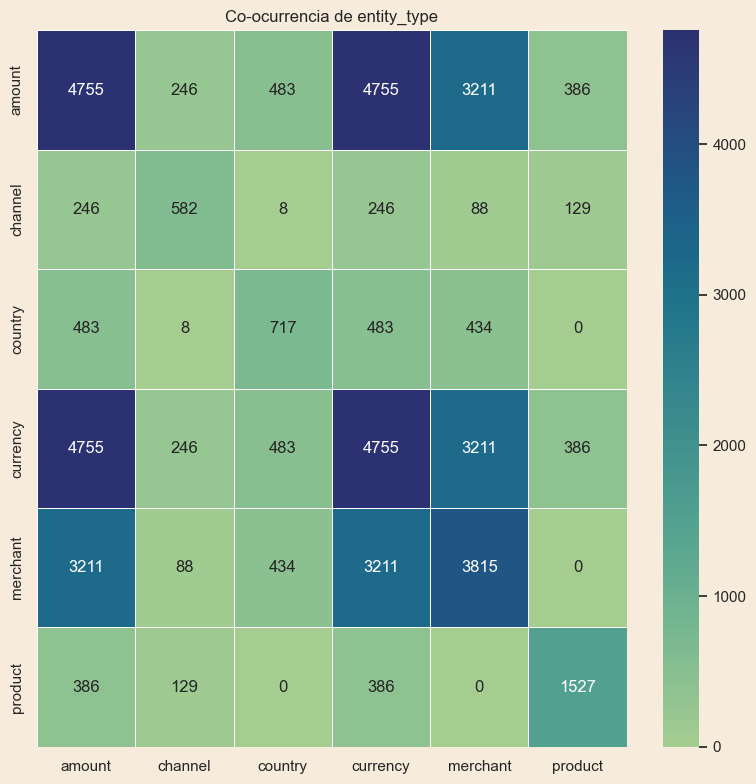

In [174]:
def coocurrencia_matrix(entities: pd.DataFrame) -> pd.DataFrame:
    """Matriz de co-ocurrencia de entity_types por conversacion."""
    all_types = sorted(entities["entity_type"].unique())
    conv_types = entities.groupby("conversation_id")["entity_type"].apply(set)
    mat = pd.DataFrame(0, index=all_types, columns=all_types)

    for ts in conv_types:
        tipos = sorted(t for t in ts if t in all_types)
        for i, t1 in enumerate(tipos):
            for t2 in tipos[i:]:
                mat.loc[t1, t2] += 1
                if t1 != t2:
                    mat.loc[t2, t1] += 1

    return mat


cooc = coocurrencia_matrix(entities)

fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_w))

plot_heatmap(
    ct=cooc,
    ax=ax,
    title="Co-ocurrencia de entity_type",
    fmt="d",
    cmap="crest"
)

plt.tight_layout()
plt.show()


Strong co-occurrence between `amount` and `currency` is expected and operationally meaningful. This dependency can improve extraction consistency but should be monitored to avoid over-reliance on coupled patterns.


### Channel vs Intent


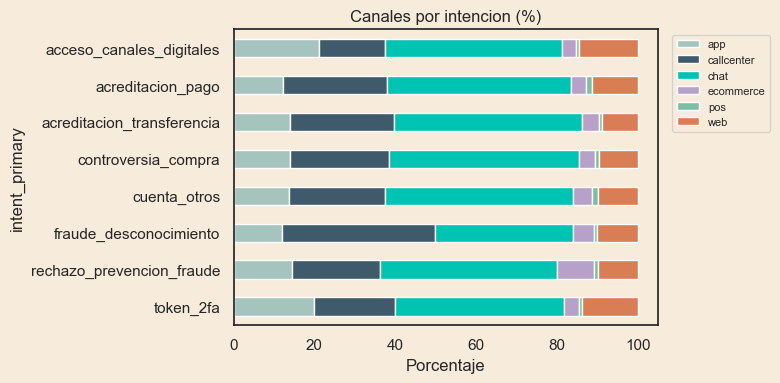

In [175]:
merged_ch = conversations[["conversation_id", "channel"]].merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

ct = crosstab_safe(merged_ch, "intent_primary", "channel")

if ct is not None:
    fig, ax = plt.subplots(1, figsize=(cfg.fig_w, cfg.fig_h))

    plot_stacked_pct(
        ct=ct,
        ax=ax,
        title="Canales por intencion (%)",
        cmap=cfg.palette
    )

    plt.tight_layout()
    plt.show()

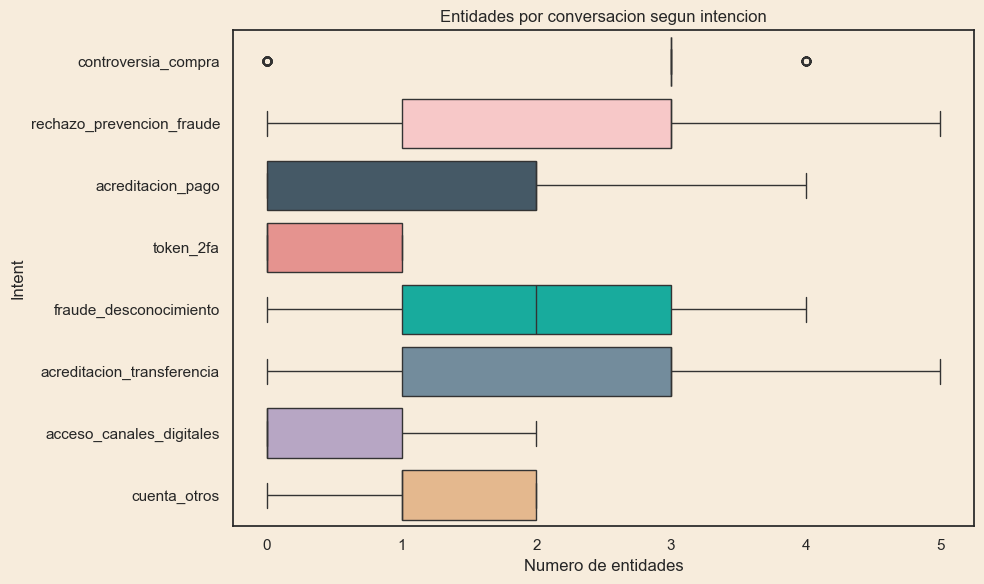

In [176]:
order_intent = conv_stats.groupby("intent_primary")["total_words"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(1, figsize=(10, 6))

sns.boxplot(
    data=conv_stats,
    x="n_entities",
    y="intent_primary",
    order=order_intent,
    palette=cfg.palette,
    ax=ax
)

ax.set_title("Entidades por conversacion segun intencion")
ax.set_xlabel("Numero de entidades")
ax.set_ylabel("Intent")

plt.tight_layout()
plt.show()

Fraud and transfer-related intents exhibit higher entity density and broader dispersion, indicating more complex informational requirements than access-oriented intents.


### Customer Segment vs Severity


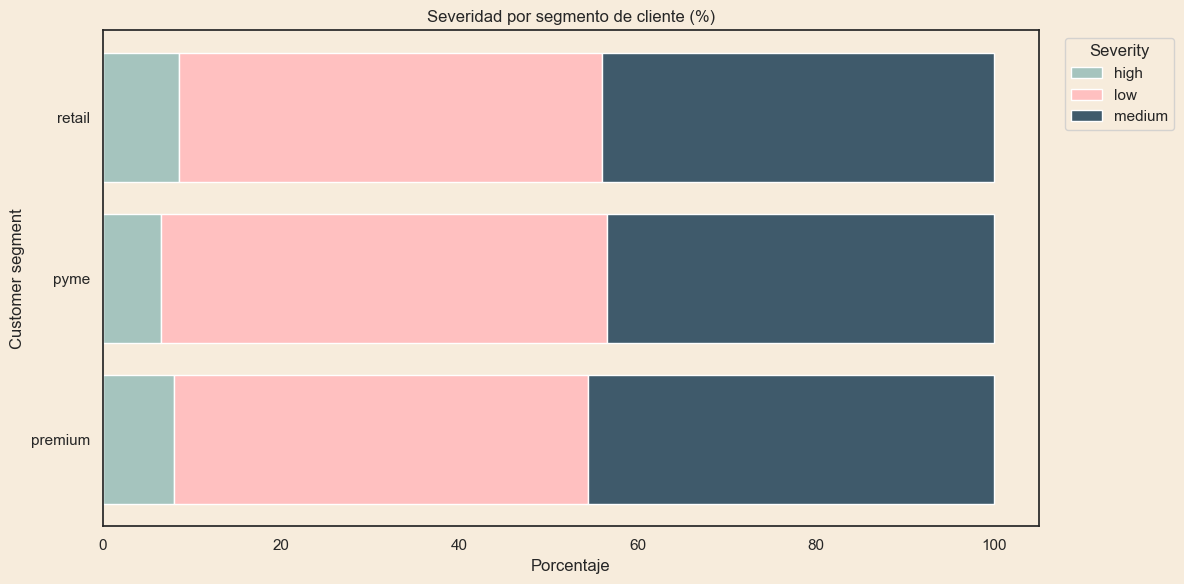

In [177]:
if check_col(conversations, "customer_segment") and check_col(labels, "severity"):

    merged_seg = conversations[["conversation_id", "customer_segment"]].merge(
        labels[["conversation_id", "severity"]],
        on="conversation_id"
    )

    ct = crosstab_safe(merged_seg, "customer_segment", "severity")

    if ct is not None:

        # Porcentaje por segmento
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

        fig, ax = plt.subplots(1, figsize=(12, 6))

        left = np.zeros(len(ct_pct.index))

        colors = sns.color_palette(cfg.palette, n_colors=len(ct_pct.columns))

        for severity, color in zip(ct_pct.columns, colors):

            ax.barh(
                ct_pct.index,
                ct_pct[severity],
                left=left,
                label=severity,
                color=color
            )

            left += ct_pct[severity].values

        ax.set_title("Severidad por segmento de cliente (%)")
        ax.set_xlabel("Porcentaje")
        ax.set_ylabel("Customer segment")

        ax.legend(
            title="Severity",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()
        plt.show()

Severity composition is similar across customer segments (`retail`, `pyme`, `premium`), suggesting segment is not a dominant driver of claim criticality in this dataset.


## Split Quality Assessment


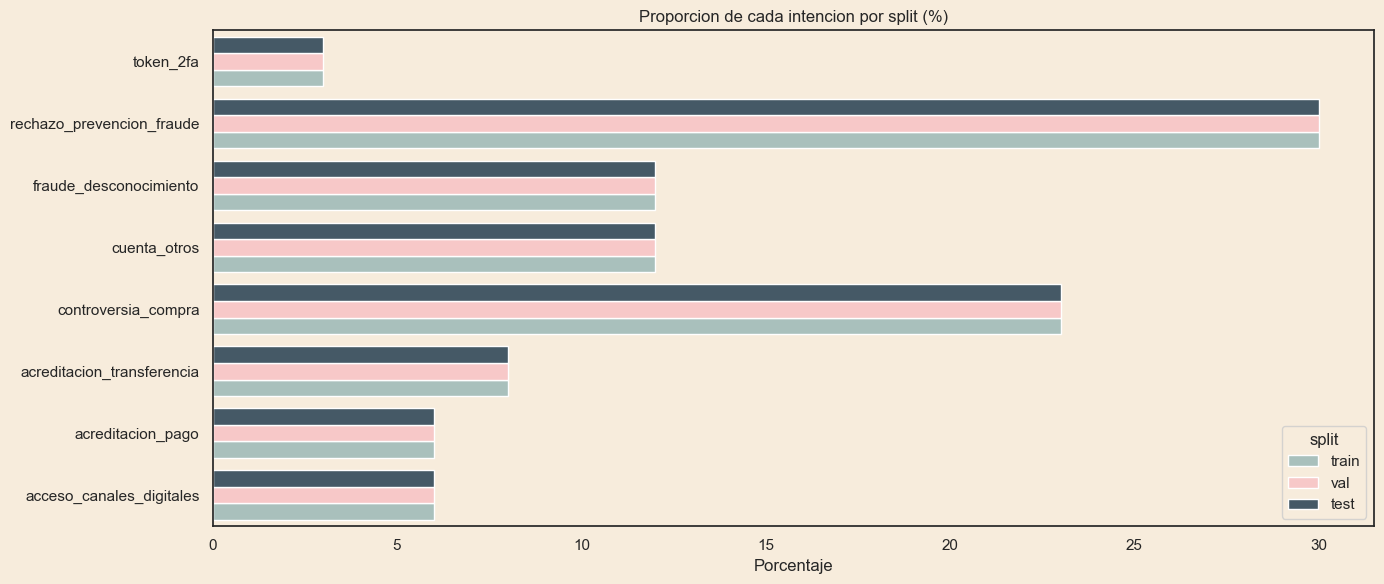

In [178]:
ct = (
    pd.crosstab(
        labels["intent_primary"],
        labels["split"],
        normalize="columns"
    ) * 100
).reset_index()

ct_long = ct.melt(
    id_vars="intent_primary",
    value_vars=["train", "val", "test"],
    var_name="split",
    value_name="pct"
)

fig, ax = plt.subplots(1, figsize=(14, 6))

sns.barplot(
    data=ct_long,
    x="pct",
    y="intent_primary",
    hue="split",
    hue_order=["train", "val", "test"],
    palette=cfg.palette,
    ax=ax
)

ax.set_title("Proporcion de cada intencion por split (%)")
ax.set_xlabel("Porcentaje")
ax.set_ylabel("")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Intent proportions across `train/val/test` are near-stratified in the original split, with no major class drift at aggregate level.


### Statistical Balance Test (Original Split)
A chi-square homogeneity test is included to verify whether category distributions differ significantly across splits. Even with balanced marginals, leakage must still be evaluated separately at text level.


In [179]:
split_test_cols = ["intent_primary", "severity", "fraud_risk", "outcome", "routing_queue"]

print("=" * 65)
print("TEST CHI-CUADRADO: Homogeneidad de distribución entre splits")
print("=" * 65)

for col in split_test_cols:
    if check_col(labels, col) and check_col(labels, "split"):
        ct_test = pd.crosstab(labels[col], labels["split"])
        chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
        resultado = "Homogéneo" if p_value > 0.05 else "Diferencias significativas"
        print(f"\n  {col}:")
        print(f"    chi2 = {chi2:.4f}, p-value = {p_value:.4f}, dof = {dof}")
        print(f"    {resultado}")

TEST CHI-CUADRADO: Homogeneidad de distribución entre splits

  intent_primary:
    chi2 = 0.0000, p-value = 1.0000, dof = 14
    Homogéneo

  severity:
    chi2 = 5.7708, p-value = 0.2169, dof = 4
    Homogéneo

  fraud_risk:
    chi2 = 0.4344, p-value = 0.9796, dof = 4
    Homogéneo

  outcome:
    chi2 = 2.3500, p-value = 0.8849, dof = 6
    Homogéneo

  routing_queue:
    chi2 = 0.0000, p-value = 1.0000, dof = 6
    Homogéneo


### Data Leakage Check: Shared Text Across Splits
Because the dataset is synthetic and phrase reuse is high, leakage is measured by checking whether identical messages appear in multiple partitions.


In [180]:
# Cruzar mensajes con el split de su conversación
msg_split = messages.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

# Textos únicos por split
train_texts = set(msg_split[msg_split["split"] == "train"]["text"].unique())
val_texts   = set(msg_split[msg_split["split"] == "val"]["text"].unique())
test_texts  = set(msg_split[msg_split["split"] == "test"]["text"].unique())

# Overlaps
train_val  = train_texts & val_texts
train_test = train_texts & test_texts
val_test   = val_texts & test_texts

print("=" * 65)
print("DATA LEAKAGE CHECK — Textos compartidos entre splits")
print("=" * 65)
print(f"\n  Textos únicos en train: {len(train_texts)}")
print(f"  Textos únicos en val:   {len(val_texts)}")
print(f"  Textos únicos en test:  {len(test_texts)}")
print(f"\n  Overlap train ∩ val:  {len(train_val):,} textos "
      f"({len(train_val)/len(val_texts)*100:.1f}% de val)")
print(f"  Overlap train ∩ test: {len(train_test):,} textos "
      f"({len(train_test)/len(test_texts)*100:.1f}% de test)")
print(f"  Overlap val ∩ test:   {len(val_test):,} textos "
      f"({len(val_test)/len(val_texts)*100:.1f}% de val)")

# Verificar a nivel de conversación completa (texto concatenado)
conv_full_text = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " [SEP] ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_full_text = conv_full_text.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

train_convs = set(conv_full_text[conv_full_text["split"] == "train"]["full_text"])
val_convs   = set(conv_full_text[conv_full_text["split"] == "val"]["full_text"])
test_convs  = set(conv_full_text[conv_full_text["split"] == "test"]["full_text"])

print(f"\n  Conversaciones completas duplicadas train ∩ val:  {len(train_convs & val_convs)}")
print(f"  Conversaciones completas duplicadas train ∩ test: {len(train_convs & test_convs)}")
print(f"  Conversaciones completas duplicadas val ∩ test:   {len(val_convs & test_convs)}")
print("=" * 65)

if len(train_test) / len(test_texts) > 0.5:
    print("\n Más del 50% de textos de test aparecen en train, se produce data leakage.")

DATA LEAKAGE CHECK — Textos compartidos entre splits

  Textos únicos en train: 3034
  Textos únicos en val:   1220
  Textos únicos en test:  1265

  Overlap train ∩ val:  1,092 textos (89.5% de val)
  Overlap train ∩ test: 1,140 textos (90.1% de test)
  Overlap val ∩ test:   709 textos (58.1% de val)

  Conversaciones completas duplicadas train ∩ val:  6
  Conversaciones completas duplicadas train ∩ test: 7
  Conversaciones completas duplicadas val ∩ test:   0

 Más del 50% de textos de test aparecen en train, se produce data leakage.


Root cause analysis confirms high lexical reuse: repeated short phrases propagate across splits even when full conversations are not exact duplicates. This can inflate benchmark metrics if left untreated.


## Class Separability Analysis (TF-IDF + PCA/t-SNE)
TF-IDF embeddings projected with t-SNE are used to evaluate lexical separability between intents and to diagnose potential over-simplification in synthetic data.


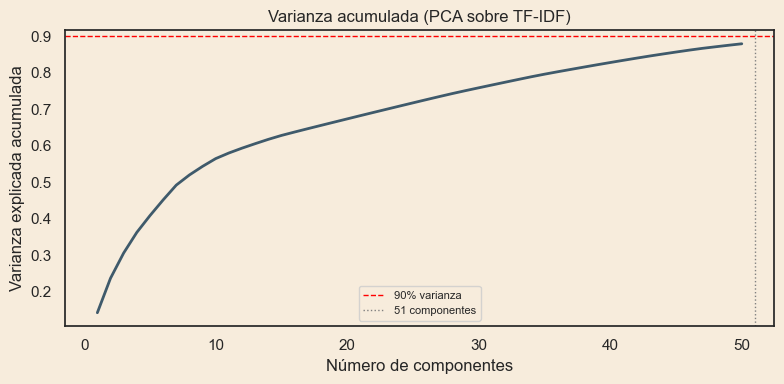


PCA: 51 componentes explican el 90% de la varianza



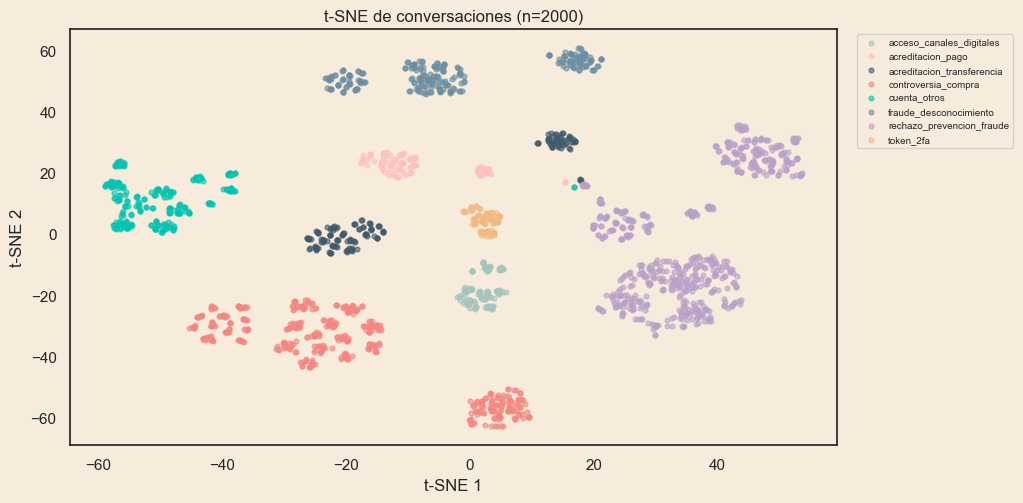

In [181]:
# Preparar texto a nivel de conversación
conv_text_sep = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_text_sep = conv_text_sep.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

# Pipeline completo
X_tsne, sample_idx, pca = compute_tsne(
    conv_text_sep["full_text"],
    n_sample=cfg.sample_pairplot,
    seed=cfg.seed
)

# PCA varianza acumulada
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.9) + 1
ax.plot(range(1, 51), cumvar, color=cfg.palette[2], linewidth=2)
ax.axhline(0.9, ls="--", color="red", lw=1, label="90% varianza")
ax.axvline(n_90, ls=":", color="gray", lw=1, label=f"{n_90} componentes")
ax.set_title("Varianza acumulada (PCA sobre TF-IDF)")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"\nPCA: {n_90} componentes explican el 90% de la varianza\n")

# t-SNE scatter
fig, ax = plt.subplots(figsize=(cfg.fig_w * 1.3, cfg.fig_h * 1.3))
plot_tsne_scatter(
    X_tsne,
    conv_text_sep["intent_primary"].iloc[sample_idx].values,
    ax, f"t-SNE de conversaciones (n={len(sample_idx)})",
    cfg.palette
)
plt.tight_layout()
plt.show()

t-SNE indicates highly separated intent clusters. This is favorable for learnability but also signals risk of lexical memorization rather than robust semantic generalization.

Mitigation strategy combines:
1. split redesign to reduce leakage,
2. text augmentation to expand lexical variability.


## Leakage and Over-Separation Mitigation


## Remediation: Re-splitting Without Text Leakage
The original split is replaced with a uniqueness-aware strategy that prioritizes conversations with rarer wording for validation and test sets.

A strict graph-grouping strategy (Union-Find) was explored and rejected because transitive overlap collapsed the corpus into a giant component. The adopted approach is more practical for this dataset topology.


In [182]:
# Score de unicidad por conversación
# Para cada conversación: promedio de (1 / frecuencia_del_texto) de sus mensajes
# Score alto = conversación con textos raros, Score bajo = textos muy repetidos
def unicidad_score(conv_texts):
    """Score de unicidad: promedio de 1/freq para cada texto de la conversación."""
    scores = [1.0 / text_conv_freq.get(t, 1) for t in conv_texts]
    return np.mean(scores) if scores else 0.0

Distribución de unicidad:
count    8000.0000
mean        0.0764
std         0.0690
min         0.0075
25%         0.0297
50%         0.0535
75%         0.0972
max         0.4446
Name: unicidad, dtype: float64


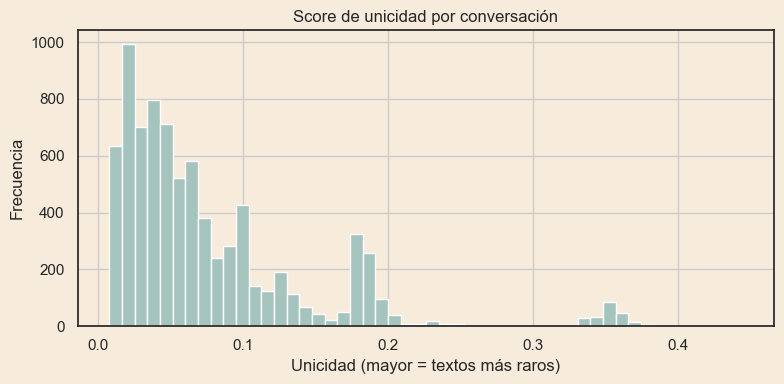


--- Nuevo split ---
split_new
train    6400
test      800
val       800
Name: count, dtype: int64

--- Verificación de leakage ---
Textos únicos en train: 2379
Textos únicos en val:   1409
Textos únicos en test:  1382
Overlap train/test: 829 textos (60.0% de test)
Overlap train/val:  1022 textos (72.5% de val)

Reducción de leakage: 90.1% → 60.0% (mejora: 30.1 puntos porcentuales)

Unicidad media por split:
split_new
test     0.2178
train    0.0520
val      0.1304
Name: unicidad, dtype: float64

--- Balance de intents por split (%) ---
split_new                   test  train   val
intent_primary                               
acceso_canales_digitales     6.0    6.0   6.0
acreditacion_pago            6.0    6.0   6.0
acreditacion_transferencia   8.0    8.0   8.0
controversia_compra         23.0   23.0  23.0
cuenta_otros                12.0   12.0  12.0
fraude_desconocimiento      12.0   12.0  12.0
rechazo_prevencion_fraude   30.0   30.0  30.0
token_2fa                    3.0    3.0   3

In [183]:
# Calcular frecuencia de cada texto en el dataset
# En cuántas conversaciones aparece cada texto?
text_conv_freq = (
    messages.drop_duplicates(subset=["conversation_id", "text"])
    .groupby("text")["conversation_id"]
    .nunique()
    .to_dict()
)

conv_unicidad = (
    messages.groupby("conversation_id")["text"]
    .apply(list)
    .reset_index(name="texts")
)
conv_unicidad["unicidad"] = conv_unicidad["texts"].apply(unicidad_score)
conv_unicidad = conv_unicidad.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

print("Distribución de unicidad:")
print(conv_unicidad["unicidad"].describe().round(4))

# Visualizar
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
conv_unicidad["unicidad"].hist(bins=50, ax=ax, color=cfg.palette[0], edgecolor="white")
ax.set_title("Score de unicidad por conversación")
ax.set_xlabel("Unicidad (mayor = textos más raros)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Ordenar por unicidad y asignar splits
# Las conversaciones con mayor unicidad van primero a val/test
# Dentro de cada intent, tomar las más únicas para val/test

conv_unicidad = conv_unicidad.sort_values("unicidad", ascending=False)

new_split = {}
for intent, group in conv_unicidad.groupby("intent_primary"):
    n_total = len(group)
    n_test = max(1, int(n_total * 0.10))
    n_val = max(1, int(n_total * 0.10))

    # Las más únicas → test, luego val, el resto → train
    sorted_group = group.sort_values("unicidad", ascending=False)
    test_ids = sorted_group.iloc[:n_test]["conversation_id"].tolist()
    val_ids = sorted_group.iloc[n_test:n_test + n_val]["conversation_id"].tolist()
    train_ids = sorted_group.iloc[n_test + n_val:]["conversation_id"].tolist()

    for cid in test_ids:
        new_split[cid] = "test"
    for cid in val_ids:
        new_split[cid] = "val"
    for cid in train_ids:
        new_split[cid] = "train"

conv_unicidad["split_new"] = conv_unicidad["conversation_id"].map(new_split)

print("\n--- Nuevo split ---")
print(conv_unicidad["split_new"].value_counts())

# Verificar reducción de leakage
msg_new = messages.merge(
    conv_unicidad[["conversation_id", "split_new"]],
    on="conversation_id"
)
new_train_texts = set(msg_new[msg_new["split_new"] == "train"]["text"].unique())
new_val_texts   = set(msg_new[msg_new["split_new"] == "val"]["text"].unique())
new_test_texts  = set(msg_new[msg_new["split_new"] == "test"]["text"].unique())

overlap_train_test = new_train_texts & new_test_texts
overlap_train_val = new_train_texts & new_val_texts

print(f"\n--- Verificación de leakage ---")
print(f"Textos únicos en train: {len(new_train_texts)}")
print(f"Textos únicos en val:   {len(new_val_texts)}")
print(f"Textos únicos en test:  {len(new_test_texts)}")
print(f"Overlap train/test: {len(overlap_train_test)} textos "
      f"({len(overlap_train_test)/len(new_test_texts)*100:.1f}% de test)")
print(f"Overlap train/val:  {len(overlap_train_val)} textos "
      f"({len(overlap_train_val)/len(new_val_texts)*100:.1f}% de val)")

# Comparar con el split original
orig_overlap = len(train_texts & test_texts) / len(test_texts) * 100
new_overlap = len(overlap_train_test) / len(new_test_texts) * 100
print(f"\nReducción de leakage: {orig_overlap:.1f}% → {new_overlap:.1f}% "
      f"(mejora: {orig_overlap - new_overlap:.1f} puntos porcentuales)")

# Unicidad media por split (test/val deberían tener mayor unicidad)
print("\nUnicidad media por split:")
print(conv_unicidad.groupby("split_new")["unicidad"].mean().round(4))

# Verificar balance de intents
print("\n--- Balance de intents por split (%) ---")
ct_new = pd.crosstab(
    conv_unicidad["intent_primary"],
    conv_unicidad["split_new"],
    normalize="columns"
) * 100
print(ct_new.round(1))

# Chi-cuadrado para verificar que el balance se mantiene
ct_counts = pd.crosstab(conv_unicidad["intent_primary"], conv_unicidad["split_new"])
chi2, p_value, _, _ = stats.chi2_contingency(ct_counts)
print(f"\nChi-cuadrado: chi2={chi2:.2f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Distribución de intents homogénea entre splits.")
else:
    print("Diferencias significativas entre splits (esperado dado el sesgo por unicidad).")

In [184]:
# Actualizar split en tablas originale
split_map = conv_unicidad.set_index("conversation_id")["split_new"]
conversations["split"] = conversations["conversation_id"].map(split_map)
labels["split"] = labels["conversation_id"].map(split_map)

## Data Augmentation for Vocabulary Diversification
Easy Data Augmentation (EDA) variants are applied to the training split to reduce lexical rigidity:
1. Random swap
2. Random deletion
3. Random insertion
4. Domain-aware synonym replacement


In [185]:
# ─── Diccionario de sinónimos del dominio bancario ───
# Mapeo manual para vocabulario frecuente del dataset
SINONIMOS_BANCARIOS = {
    "tarjeta": ["plástico", "card", "medio de pago"],
    "rechazada": ["denegada", "no autorizada", "bloqueada"],
    "rechazaron": ["denegaron", "no autorizaron", "bloquearon"],
    "compra": ["transacción", "operación", "adquisición"],
    "comercio": ["establecimiento", "local", "negocio", "tienda"],
    "monto": ["importe", "valor", "suma", "cantidad"],
    "cuenta": ["cta", "producto bancario"],
    "transferencia": ["envío", "giro", "movimiento"],
    "reclamo": ["queja", "inconveniente", "problema", "incidencia"],
    "fraude": ["uso no autorizado", "operación desconocida"],
    "débito": ["extracción", "cargo"],
    "crédito": ["línea", "financiación"],
    "banco": ["entidad", "institución", "sucursal"],
    "cliente": ["usuario", "titular"],
    "pago": ["abono", "liquidación"],
    "acreditación": ["depósito", "ingreso"],
    "token": ["código", "clave dinámica", "verificador"],
    "digital": ["electrónico", "virtual", "online"],
    "bloqueo": ["suspensión", "inhabilitación"],
    "problema": ["inconveniente", "dificultad", "situación"],
}

In [186]:
def augment_synonym_replace(text: str, p_replace: float = 0.15) -> str:
    """Reemplaza palabras por sinónimos del dominio bancario."""
    words = text.split()
    new_words = []
    for w in words:
        w_lower = w.lower().rstrip(".,;:!?")
        if w_lower in SINONIMOS_BANCARIOS and random.random() < p_replace:
            sinonimo = random.choice(SINONIMOS_BANCARIOS[w_lower])
            # Preservar mayúscula si la palabra original la tenía
            if w[0].isupper():
                sinonimo = sinonimo.capitalize()
            new_words.append(sinonimo)
        else:
            new_words.append(w)
    return " ".join(new_words)


def augment_random_swap(text: str, n_swaps: int = 2) -> str:
    """Intercambia posiciones de n pares de palabras aleatorias."""
    words = text.split()
    if len(words) < 4:
        return text
    for _ in range(n_swaps):
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)


def augment_random_deletion(text: str, p_delete: float = 0.1) -> str:
    """Elimina cada palabra con probabilidad p_delete."""
    words = text.split()
    if len(words) <= 2:
        return text
    remaining = [w for w in words if random.random() > p_delete]
    return " ".join(remaining) if remaining else " ".join(words[:2])


def augment_random_insertion(text: str, p_insert: float = 0.1) -> str:
    """Duplica una palabra aleatoria del texto en posición aleatoria."""
    words = text.split()
    if len(words) < 2:
        return text
    new_words = list(words)
    n_insertions = max(1, int(len(words) * p_insert))
    for _ in range(n_insertions):
        insert_pos = random.randint(0, len(new_words))
        random_word = random.choice(words)
        new_words.insert(insert_pos, random_word)
    return " ".join(new_words)


def augment_conversation(text: str, n_augments: int = 3) -> list:
    """Genera n variantes aumentadas combinando técnicas."""
    augmenters = [
        augment_synonym_replace,
        augment_random_swap,
        augment_random_deletion,
        augment_random_insertion,
    ]
    variants = []
    for _ in range(n_augments):
        aug_text = text
        # Aplicar 1-2 técnicas en cadena para mayor variabilidad
        n_techniques = random.choice([1, 2])
        selected = random.sample(augmenters, n_techniques)
        for fn in selected:
            aug_text = fn(aug_text)
        variants.append(aug_text)
    return variants

In [187]:
# Construir texto concatenado por conversación
# (se recomputa para garantizar consistencia con el split actualizado)
conv_full_text = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " [SEP] ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_full_text = conv_full_text.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

# Aplicar augmentation solo a TRAIN
train_convs_aug = conv_full_text[conv_full_text["split"] == "train"].copy()
train_convs_aug = train_convs_aug.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

print(f"Conversaciones de train: {len(train_convs_aug)}")

N_AUGMENTS = cfg.n_augments  # variantes por conversación

augmented_rows = []
for _, row in train_convs_aug.iterrows():
    variants = augment_conversation(row["full_text"], n_augments=N_AUGMENTS)
    for k, v in enumerate(variants):
        augmented_rows.append({
            "conversation_id": f"{row['conversation_id']}_aug{k}",
            "full_text": v,
            "intent_primary": row["intent_primary"],
            "split": "train",
            "is_augmented": True,
        })

df_augmented = pd.DataFrame(augmented_rows)
print(f"Variantes generadas: {len(df_augmented)}")
print(f"Total train (original + augmented): {len(train_convs_aug) + len(df_augmented)}")

# Mostrar ejemplos
print("\n--- Ejemplos de augmentation ---")
sample = train_convs_aug.iloc[0]
print(f"\nOriginal ({sample['intent_primary']}):")
print(f"  {sample['full_text'][:150]}...")

sample_variants = augment_conversation(sample["full_text"], n_augments=3)
for i, v in enumerate(sample_variants):
    print(f"\nVariante {i+1}:")
    print(f"  {v[:150]}...")

Conversaciones de train: 6400
Variantes generadas: 19200
Total train (original + augmented): 25600

--- Ejemplos de augmentation ---

Original (rechazo_prevencion_fraude):
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de débito. [SEP] Me figura autorización rechazada  por 89.00 EUR. [SEP] Bi...

Variante 1:
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de cargo [SEP] Me figura autorización rechazada por 89.00 EUR. [SEP] Bien,...

Variante 2:
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de débito. [SEP] Me figura autorización rechazada por 89.00 EUR. [SEP] Bie...

Variante 3:
  internacional? buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de débito. [SEP] Me figura autorización internet por 89.00 EUR. [...


## t-SNE Before vs After Augmentation
This comparison evaluates whether augmentation increases boundary overlap and reduces artificial class isolation.


Total: 25600 (6400 orig + 19200 aug)


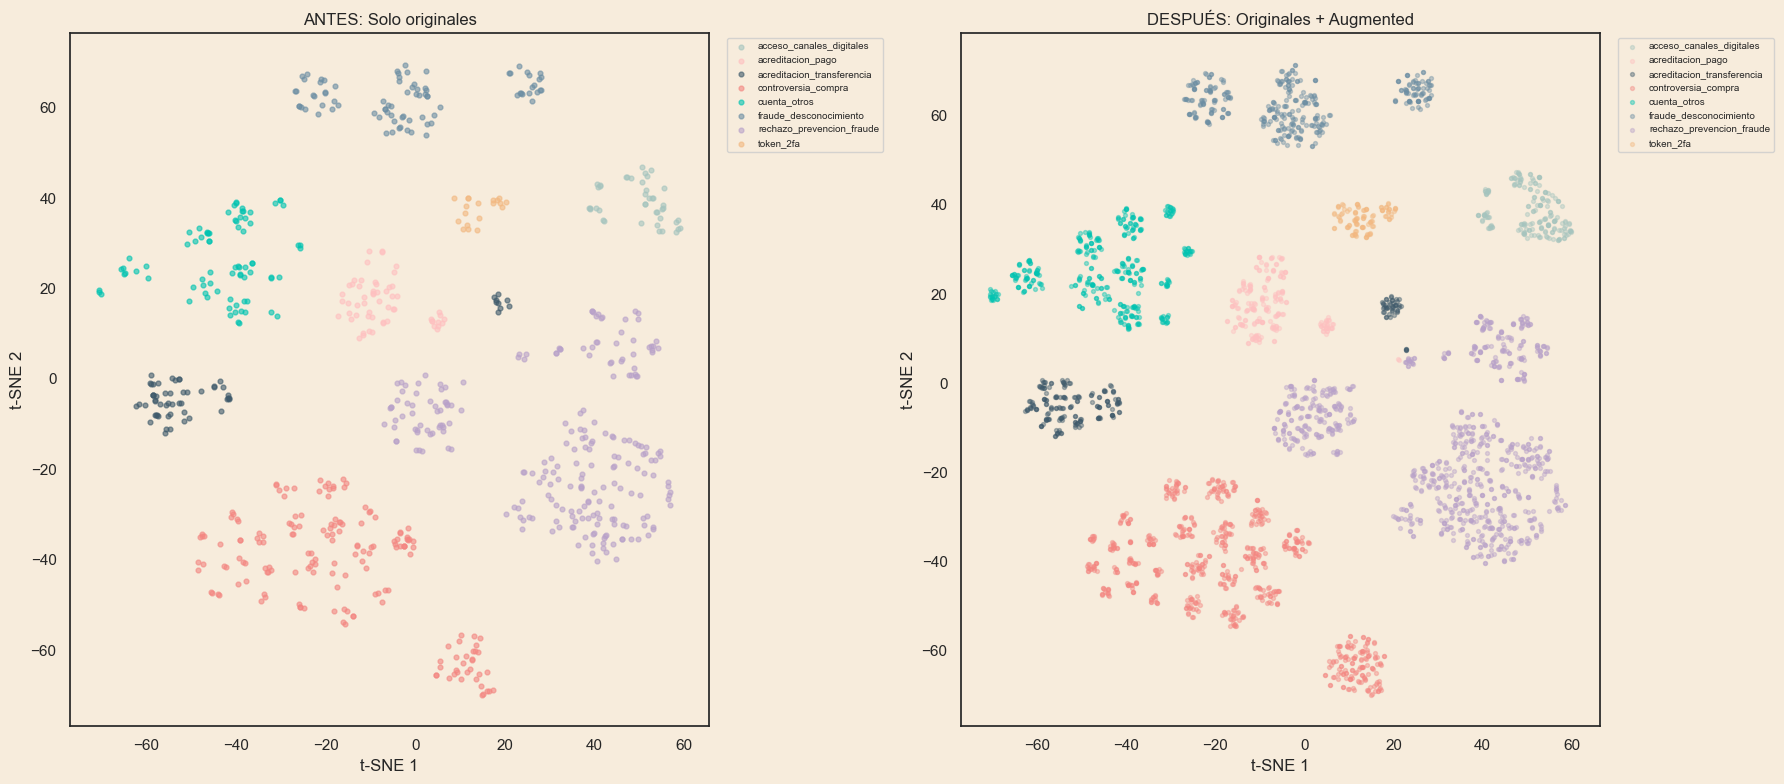

In [188]:
# Dataset combinado
train_original = train_convs_aug[["full_text", "intent_primary"]].copy()
train_original["source"] = "original"
train_aug_labeled = df_augmented[["full_text", "intent_primary"]].copy()
train_aug_labeled["source"] = "augmented"
combined = pd.concat([train_original, train_aug_labeled], ignore_index=True)

print(f"Total: {len(combined)} ({len(train_original)} orig + {len(train_aug_labeled)} aug)")

# Un solo pipeline para todo
X_comb_tsne, idx_s, _ = compute_tsne(
    combined["full_text"], n_sample=3000, seed=cfg.seed
)

intents_s = combined["intent_primary"].iloc[idx_s].values
sources_s = combined["source"].iloc[idx_s].values

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(cfg.fig_w * 2 + 2, cfg.fig_h * 2))

plot_tsne_scatter(X_comb_tsne, intents_s, axes[0],
                  "ANTES: Solo originales", cfg.palette,
                  mask=(sources_s == "original"))

plot_tsne_scatter(X_comb_tsne, intents_s, axes[1],
                  "DESPUÉS: Originales + Augmented", cfg.palette,
                  s=8, alpha=0.4)

plt.tight_layout()
plt.show()

### Augmentation Impact on Separability
Post-augmentation projections still show limited overlap, so augmentation improves robustness only marginally. Stronger paraphrastic generation (for example, controlled LLM rewrites) is a more promising next step.


## Key Insights
1. The dataset is structurally strong for conversation-level NLP modeling.
2. Message-level leakage in the original split is material and must be mitigated before reporting final metrics.
3. Synthetic generation yields highly separable lexical clusters; this can overestimate real-world generalization.
4. `intent_secondary` is too sparse for reliable supervised training.

## Conclusion
The EDA confirms that the project is technically viable, but trustworthy evaluation requires leakage-aware splitting and stronger lexical diversification. The resulting recommendations directly inform the modeling notebook configuration.


## Reproducibility: Persisting the Processed Dataset
This section exports the cleaned and split-adjusted tables so training can be reproduced with the same data state used in the analysis.


In [189]:
def ensure_dir(path: str) -> None:
    """Crea el directorio si no existe."""
    os.makedirs(path, exist_ok=True)

def save_dataframes_to_csv(
    out_dir: str,
    conversations,
    messages,
    labels,
    entities,
    index: bool = False
) -> dict:
    """
    Guarda los dataframes en CSV con los nombres esperados.
    Devuelve un dict con paths generados.
    """
    ensure_dir(out_dir)

    paths = {
        "conversations": os.path.join(out_dir, "conversations.csv"),
        "messages": os.path.join(out_dir, "messages.csv"),
        "labels": os.path.join(out_dir, "labels.csv"),
        "entities": os.path.join(out_dir, "entities.csv"),
    }

    conversations.to_csv(paths["conversations"], index=index)
    messages.to_csv(paths["messages"], index=index)
    labels.to_csv(paths["labels"], index=index)
    entities.to_csv(paths["entities"], index=index)

    return paths

def zip_folder(
    folder_path: str,
    zip_path: str,
    include_root: bool = False
) -> None:
    """
    Crea un zip de todo el contenido de folder_path.
    - include_root=False: mete los archivos al root del zip (recomendado para tu caso)
    - include_root=True: incluye la carpeta contenedora dentro del zip
    """
    folder_path = os.path.abspath(folder_path)
    root_name = os.path.basename(folder_path)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(folder_path):
            for file in files:
                abs_file = os.path.join(root, file)
                rel = os.path.relpath(abs_file, folder_path)

                arcname = os.path.join(root_name, rel) if include_root else rel
                zf.write(abs_file, arcname=arcname)

def sanity_check_columns(original_df, modified_df, name: str) -> None:
    """
    Validación simple: mismas columnas (mismo set y orden).
    Ajustá si tu pipeline permite columnas nuevas.
    """
    if list(original_df.columns) != list(modified_df.columns):
        raise ValueError(
            f"Las columnas de '{name}' cambiaron.\n"
            f"Original: {list(original_df.columns)}\n"
            f"Nuevo:    {list(modified_df.columns)}"
        )

def build_training_zip(
    base_extract_dir: str,
    conversations,
    messages,
    labels,
    entities,
    zip_name_prefix: str = "claimstruct_multitable_v2_clean",
    validate_against_original: bool = False
) -> str:
    """
    Guarda CSVs modificados y genera un ZIP listo para entrenamiento.
    - base_extract_dir: donde está el dataset original extraído (para tomar referencia si validás)
    - validate_against_original: si True, valida columnas contra los CSV originales.
    Devuelve path al zip generado.
    """
    # Timestamp para versionado simple
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    out_dir = f"{zip_name_prefix}_{stamp}"
    ensure_dir(out_dir)

    # Validación opcional contra originales
    if validate_against_original:
        orig_conversations = safe_read_csv(os.path.join(base_extract_dir, "conversations.csv"))
        orig_messages = safe_read_csv(os.path.join(base_extract_dir, "messages.csv"))
        orig_labels = safe_read_csv(os.path.join(base_extract_dir, "labels.csv"))
        orig_entities = safe_read_csv(os.path.join(base_extract_dir, "entities.csv"))

        sanity_check_columns(orig_conversations, conversations, "conversations")
        sanity_check_columns(orig_messages, messages, "messages")
        sanity_check_columns(orig_labels, labels, "labels")
        sanity_check_columns(orig_entities, entities, "entities")

    # Guardar CSVs
    paths = save_dataframes_to_csv(
        out_dir=out_dir,
        conversations=conversations,
        messages=messages,
        labels=labels,
        entities=entities,
        index=False
    )

    print("CSVs guardados:")
    for k, v in paths.items():
        print(f" - {k}: {v}")

    # Crear ZIP
    zip_path = f"{zip_name_prefix}_{stamp}.zip"
    zip_folder(out_dir, zip_path, include_root=False)

    print(f"\nZIP generado: {zip_path}")
    return zip_path

In [190]:
zip_path = build_training_zip(
    base_extract_dir=extract_dir,
    conversations=conversations,
    messages=messages,
    labels=labels,
    entities=entities,
    zip_name_prefix="claimstruct_multitable_v2_for_training",
    validate_against_original=False
)

CSVs guardados:
 - conversations: claimstruct_multitable_v2_for_training_20260312_004847/conversations.csv
 - messages: claimstruct_multitable_v2_for_training_20260312_004847/messages.csv
 - labels: claimstruct_multitable_v2_for_training_20260312_004847/labels.csv
 - entities: claimstruct_multitable_v2_for_training_20260312_004847/entities.csv

ZIP generado: claimstruct_multitable_v2_for_training_20260312_004847.zip
